# 00. 문제 정의


## 핵심 질문
**"초기 100사이클 데이터만으로 배터리의 최종 수명 등급(A/B/C/불량)을 예측할 수 있는가?"**

## 비즈니스 가치
- **현재**: 출하 전 2주간 에이징 테스트로 등급 판정 → 막대한 재고비용
- **목표**: 초기 수 시간 데이터로 등급 예측 → 에이징 테스트 대체

## 3단계 분석
1. **양품/불량 이진 분류**: 시장 출하 가능 여부
2. **양품 내 A/B/C Grade 분류**: 시장 세분화 (EV/ESS/저가품)
3. **재고비용 최적화**: 조기 판정으로 절감 효과 정량화

## 데이터
- **출처**: Severson et al. (2019), *Nature Energy* (Stanford + MIT + Toyota)
- **규모**: 135개 LFP/흑연 18650 셀, 72개 충전 프로토콜
- **라이선스**: CC BY 4.0



# 01.기본 환경 세팅 및 데이터 파싱


## 01-1. 기본 세팅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/battery_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"✅ 프로젝트 폴더: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 프로젝트 폴더: /content/drive/MyDrive/battery_project


In [ ]:
!pip install h5py shap tqdm statsmodels scipy -q

import json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm.notebook import tqdm

# 한글 폰트 (있으면 사용)
font_path = '/content/drive/MyDrive/Colab Notebooks/DArt-B/26-1_AF/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

print("✅ 패키지 + 폰트 준비 완료")

✅ 패키지 + 폰트 준비 완료


# 02.데이터 추출 (JSON → CSV)

원본 데이터는 셀당 1개의 JSON 파일로 구성되어 있다.
이번에 추출하는 컬럼은 12개로, 기존 8개에서 다음 4개를 추가했다.

| 추가 컬럼 | 의미 | 활용 |
|----------|------|------|
| `discharge_energy` | 방전 에너지 (Wh) | 에너지 효율 계산 |
| `charge_energy` | 충전 에너지 (Wh) | 에너지 효율 계산 |
| `temperature_minimum` | 최저 온도 | 온도 범위 계산 |
| `energy_efficiency` | 에너지 효율 | **논문에서 사용한 피처** |
| `charge_throughput` | 누적 충전량 | 노화 누적 지표 |
| `charge_duration` | 충전 소요 시간 | **충전 속도 변화 = 노화 신호** |



## 02-1. 데이터 다운로드 (최초 1회)

In [ ]:
import urllib.request
import zipfile

ZIP_PATH = f'{PROJECT_DIR}/FastCharge.zip'
EXTRACT_DIR = f'{PROJECT_DIR}/data'

if os.path.exists(ZIP_PATH) and os.path.exists(EXTRACT_DIR):
    n_files = len([f for f in os.listdir(EXTRACT_DIR) if f.endswith('.json')])
    print(f"✅ 이미 준비됨 (JSON {n_files}개)")
else:
    if not os.path.exists(ZIP_PATH):
        print("⏳ ZIP 다운로드 중...")
        URL = "https://s3.amazonaws.com/publications.matr.io/1/final_data/FastCharge.zip"
        urllib.request.urlretrieve(URL, ZIP_PATH)
        print("✅ 다운로드 완료")

    if not os.path.exists(EXTRACT_DIR):
        print("📂 압축 해제 중...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(EXTRACT_DIR)
        print("✅ 압축 해제 완료")

✅ 이미 준비됨 (JSON 140개)


## 02-2. JSON 구조 확인 (데이터 이해)

In [ ]:
json_files = sorted([f for f in os.listdir(EXTRACT_DIR) if f.endswith('.json')])
print(f"총 JSON 파일: {len(json_files)}개\n")

with open(f'{EXTRACT_DIR}/{json_files[0]}', 'r') as f:
    sample = json.load(f)

print("📁 최상위 키:")
for key, val in sample.items():
    if isinstance(val, dict):
        print(f"  [{key}]: dict")
    elif isinstance(val, list):
        print(f"  [{key}]: list (길이={len(val)})")
    elif val is None:
        print(f"  [{key}]: None")
    else:
        print(f"  [{key}]: {val}")

print(f"\n📁 summary 컬럼 (이게 우리가 쓸 데이터):")
for k, v in sample['summary'].items():
    if isinstance(v, list) and v:
        first_val = v[0]
        if isinstance(first_val, (int, float)):
            print(f"  {k}: 길이={len(v)}, 첫값={round(first_val, 4)}")
        else:
            print(f"  {k}: 길이={len(v)}, 첫값={first_val}")

총 JSON 파일: 140개

📁 최상위 키:
  [@module]: beep.structure
  [@class]: ProcessedCyclerRun
  [barcode]: el150800440551
  [protocol]: 2017-06-30_tests\20170630-4_4C_55per_6C.sdu
  [channel_id]: 18
  [summary]: dict
  [cycles_interpolated]: dict
  [diagnostic_summary]: None
  [diagnostic_interpolated]: None
  [@version]: 2020.10.19.20-8667111

📁 summary 컬럼 (이게 우리가 쓸 데이터):
  cycle_index: 길이=491, 첫값=0
  discharge_capacity: 길이=491, 첫값=1.9346
  charge_capacity: 길이=491, 첫값=1.4174
  discharge_energy: 길이=491, 첫값=6.1161
  charge_energy: 길이=491, 첫값=4.673
  dc_internal_resistance: 길이=491, 첫값=0.0294
  temperature_maximum: 길이=491, 첫값=34.169
  temperature_average: 길이=491, 첫값=30.9777
  temperature_minimum: 길이=491, 첫값=25.2379
  date_time_iso: 길이=491, 첫값=2017-07-01T03:52:32+00:00
  energy_efficiency: 길이=491, 첫값=1.3088
  charge_throughput: 길이=491, 첫값=1.4174
  energy_throughput: 길이=491, 첫값=4.673
  charge_duration: 길이=491, 첫값=33280.0
  time_temperature_integrated: 길이=491, 첫값=39217.3815
  paused: 길이=491, 첫값=0


In [ ]:
# 기존 01-2 셀을 지우고 이 코드로 덮어쓰세요.
!pip install h5py shap tqdm statsmodels scipy -q
# 우분투(코랩) 환경에 나눔글꼴 설치
!sudo apt-get install -y fonts-nanum -q

import json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm.notebook import tqdm

# 설치된 시스템 폰트 경로를 직접 캐시에 추가 (런타임 재시작 불필요)
sys_font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(sys_font_path):
    fm.fontManager.addfont(sys_font_path)
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지
plt.rcParams['figure.dpi'] = 110

print("✅ 패키지 + 코랩 내장 폰트 준비 완료")

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 9 not upgraded.
✅ 패키지 + 코랩 내장 폰트 준비 완료


## 02-3. CSV 생성 (12개 컬럼)

⚠️ **약 18분 소요**. 한 번만 실행하고 이후엔 02-4로 바로 로드.

In [ ]:
CSV_PATH = f'{PROJECT_DIR}/battery_cycles.csv'

# 추출할 12개 컬럼
COLS = [
    'cycle_index',
    'discharge_capacity',
    'charge_capacity',
    'discharge_energy',          # ← NEW
    'charge_energy',             # ← NEW
    'dc_internal_resistance',
    'temperature_average',
    'temperature_maximum',
    'temperature_minimum',       # ← NEW
    'energy_efficiency',         # ← NEW (논문 피처)
    'charge_throughput',         # ← NEW
    'charge_duration',           # ← NEW (충전 시간)
]

# 기존 CSV가 12개 컬럼인지 확인
need_rebuild = True
if os.path.exists(CSV_PATH):
    existing = pd.read_csv(CSV_PATH, nrows=0)
    expected_cols = set(COLS + ['barcode', 'protocol'])
    if expected_cols.issubset(set(existing.columns)):
        need_rebuild = False
        print(f"✅ 기존 CSV에 모든 컬럼 있음 ({len(existing.columns)}개)")

if need_rebuild:
    print(f"⏳ CSV 생성 중 (12 컬럼, 약 18분)...")
    all_rows = []

    for fname in tqdm(json_files, desc="변환"):
        try:
            with open(f'{EXTRACT_DIR}/{fname}', 'r') as f:
                data = json.load(f)

            summary  = data['summary']
            barcode  = data.get('barcode', '')
            protocol = data.get('protocol', '').split('\\')[-1].replace('.sdu', '')
            n_cycles = len(summary['cycle_index'])

            for j in range(n_cycles):
                row = {'barcode': barcode, 'protocol': protocol}
                for col in COLS:
                    vals = summary.get(col, [])
                    row[col] = vals[j] if j < len(vals) else None
                all_rows.append(row)

            del data
        except Exception as e:
            print(f"⚠️ {fname}: {e}")

    df = pd.DataFrame(all_rows)
    df.to_csv(CSV_PATH, index=False)
    print(f"✅ 저장 완료: {df.shape}")
else:
    df = pd.read_csv(CSV_PATH)
    print(f"형태: {df.shape}")

✅ 기존 CSV에 모든 컬럼 있음 (14개)
형태: (114314, 14)


## 02-4. CSV 로드 + 전처리 (재시작 후엔 여기부터)

In [ ]:
# CSV 로드
df = pd.read_csv(CSV_PATH)

# 전처리
# ① cycle 0 제거 — 초기화 사이클이라 이상값 (Qd ≈ 1.9, 정상은 1.05)
# ② dc_internal_resistance = 0 제거 — 측정 오류
df_clean = df[df['cycle_index'] > 0].copy()
df_clean = df_clean[df_clean['dc_internal_resistance'] > 0]

# Matplotlib 설정 추가: 축 라벨이 나타나지 않는 문제 해결 시도
# 이 설정은 일반적으로 노트북 초반의 환경 설정 셀에 위치하는 것이 좋지만,
# 문제 해결을 위한 임시 조치로 여기에 포함합니다.
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False # 한글 폰트 사용 시 마이너스 기호 깨짐 방지
plt.rcParams['figure.autolayout'] = True   # 플롯 레이아웃 자동 조정 (축 라벨 겹침/잘림 방지)

print(f"원본:      {df.shape}")
print(f"전처리 후: {df_clean.shape}")
print(f"셀 수:    {df_clean['barcode'].nunique()}개")
print(f"프로토콜: {df_clean['protocol'].nunique()}가지")
print()
print(df_clean.head())

원본:      (114314, 14)
전처리 후: (114130, 14)
셀 수:    134개
프로토콜: 72가지

          barcode                protocol  cycle_index  discharge_capacity  \
1  el150800440551  20170630-4_4C_55per_6C            1            1.045426   
2  el150800440551  20170630-4_4C_55per_6C            2            1.048037   
3  el150800440551  20170630-4_4C_55per_6C            3            1.048029   
4  el150800440551  20170630-4_4C_55per_6C            4            1.049100   
5  el150800440551  20170630-4_4C_55per_6C            5            1.049680   

   charge_capacity  discharge_energy  charge_energy  dc_internal_resistance  \
1         1.045648          3.173665       3.646161                0.017864   
2         1.048442          3.176155       3.651186                0.017929   
3         1.047885          3.175840       3.651785                0.018012   
4         1.049186          3.182562       3.653328                0.017671   
5         1.049651          3.180693       3.654495                0.

# 03. 프로토콜 딥다이브 — 최장수 vs 최단명

72가지 충전 프로토콜 중 **수명이 가장 긴 것**과 **가장 짧은 것**을 골라 비교한다.
같은 배터리(LFP 18650 셀)인데 충전 방식이 다르면 얼마나 차이 나는지를 시각적으로 확인.



## 03-1. 셀별 cycle_life 계산

In [ ]:
# ════════════════════════════════════════════════════════
# [조절 가능 파라미터]
# ────────────────────────────────────────────────────────
EOL_RATIO = 0.80      # 수명 종료 기준 (초기 용량의 80% = 업계 표준)
# ════════════════════════════════════════════════════════

def calc_cycle_life(g):
    g = g.sort_values('cycle_index')
    Qd = g['discharge_capacity'].values
    if len(Qd) < 10:
        return None
    ref = Qd[:10].max()  # 초기 10사이클의 최댓값 = 기준 용량
    eol = np.where(Qd < ref * EOL_RATIO)[0]
    return int(eol[0]) if len(eol) > 0 else len(Qd)

cell_life = (df_clean.groupby('barcode')
                     .apply(calc_cycle_life, include_groups=False)
                     .dropna()
                     .astype(int)
                     .reset_index()
                     .rename(columns={0: 'cycle_life'}))

# 프로토콜 정보 붙이기
proto_map = df_clean.drop_duplicates('barcode')[['barcode','protocol']]
cell_life = cell_life.merge(proto_map, on='barcode')

print(f"셀 수: {len(cell_life)}개")
print(f"\n수명 통계:")
print(cell_life['cycle_life'].describe().round(0))

셀 수: 134개

수명 통계:
count     134.0
mean      846.0
std       412.0
min       157.0
25%       512.0
50%       792.0
75%      1007.0
max      2237.0
Name: cycle_life, dtype: float64


## 03-2. 최장수 / 최단명 프로토콜 선정

In [ ]:
# 프로토콜별 중앙값 수명
proto_median = (cell_life.groupby('protocol')['cycle_life']
                         .agg(['median', 'count'])
                         .query('count >= 1')
                         .sort_values('median'))

# ════════════════════════════════════════════════════════
# [조절 가능 — 다른 프로토콜로 비교하고 싶으면 여기 수정]
# ────────────────────────────────────────────────────────
LONGEST_PROTO  = proto_median.index[-1]   # 중앙값 최대
SHORTEST_PROTO = proto_median.index[0]    # 중앙값 최소
# ════════════════════════════════════════════════════════

print(f"📈 최장수 프로토콜: {LONGEST_PROTO}")
print(f"   중앙값 수명: {proto_median.loc[LONGEST_PROTO, 'median']:.0f} 사이클")
print(f"   셀 수:      {proto_median.loc[LONGEST_PROTO, 'count']:.0f}개")
print()
print(f"📉 최단명 프로토콜: {SHORTEST_PROTO}")
print(f"   중앙값 수명: {proto_median.loc[SHORTEST_PROTO, 'median']:.0f} 사이클")
print(f"   셀 수:      {proto_median.loc[SHORTEST_PROTO, 'count']:.0f}개")
print()
print(f"수명 격차: {proto_median.loc[LONGEST_PROTO,'median'] / proto_median.loc[SHORTEST_PROTO,'median']:.1f}배")

📈 최장수 프로토콜: 20170512-3_6C-80PER_3_6C.SDU
   중앙값 수명: 2157 사이클
   셀 수:      3개

📉 최단명 프로토콜: 20170629-2C_10per_6C
   중앙값 수명: 157 사이클
   셀 수:      1개

수명 격차: 13.7배


## 03-3. 두 프로토콜의 시계열 비교 (모든 변수)

/tmp/ipykernel_19280/1103106896.py:31: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_19280/1103106896.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


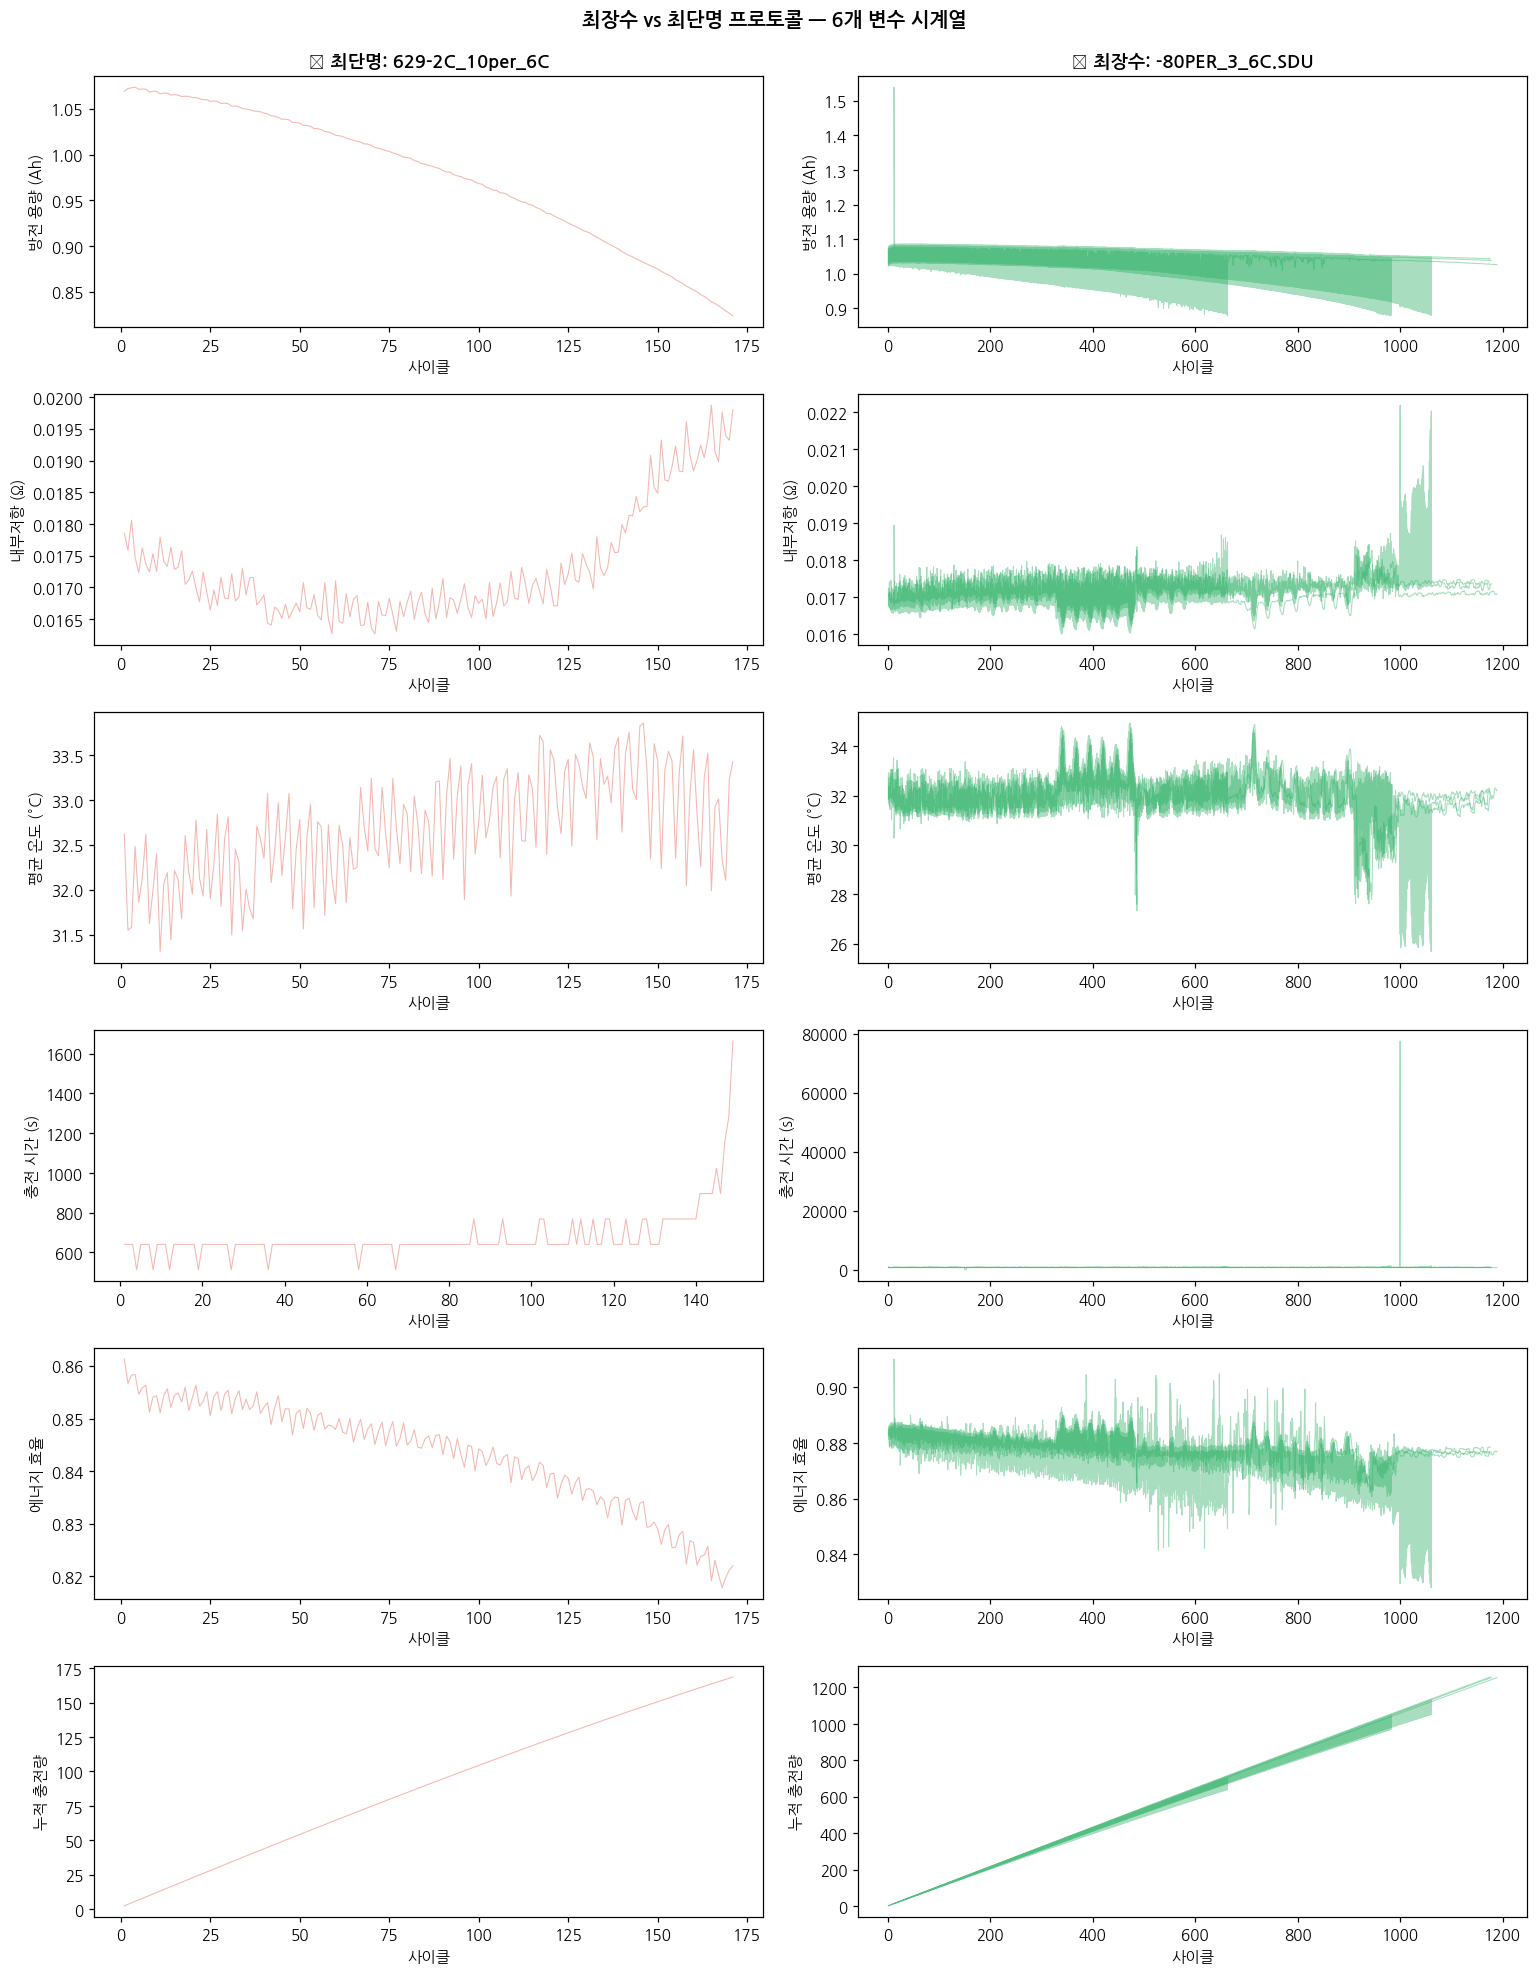

In [ ]:
VARS = ['discharge_capacity', 'dc_internal_resistance',
        'temperature_average', 'charge_duration',
        'energy_efficiency', 'charge_throughput']
VAR_LABELS = ['방전 용량 (Ah)', '내부저항 (Ω)',
              '평균 온도 (°C)', '충전 시간 (s)',
              '에너지 효율', '누적 충전량']

fig, axes = plt.subplots(len(VARS), 2, figsize=(14, 3*len(VARS)))
fig.suptitle('최장수 vs 최단명 프로토콜 — 6개 변수 시계열',
             fontsize=13, fontweight='bold', y=0.995)

for col_idx, (proto, title, color) in enumerate([
    (SHORTEST_PROTO, f'📉 최단명: {SHORTEST_PROTO[-15:]}', '#e74c3c'),
    (LONGEST_PROTO,  f'📈 최장수: {LONGEST_PROTO[-15:]}', '#27ae60'),
]):
    sub_df = df_clean[df_clean['protocol'] == proto]
    barcodes = sub_df['barcode'].unique()

    for row_idx, (var, var_label) in enumerate(zip(VARS, VAR_LABELS)):
        ax = axes[row_idx, col_idx]
        for bc in barcodes:
            cell_data = sub_df[sub_df['barcode'] == bc].sort_values('cycle_index')
            ax.plot(cell_data['cycle_index'], cell_data[var],
                    color=color, alpha=0.4, linewidth=0.7)

        ax.set_xlabel('사이클')
        ax.set_ylabel(var_label)
        if row_idx == 0:
            ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

## 03-4. 두 프로토콜 셀 간 산포 (Within-Protocol Variability)

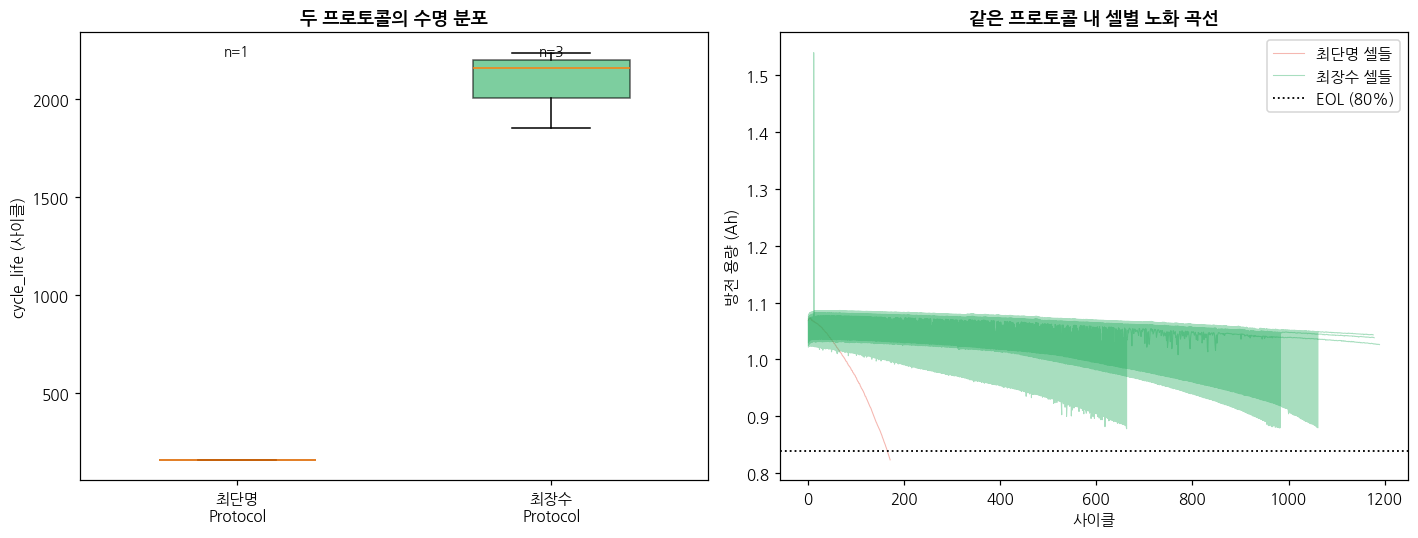

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ① 두 프로토콜 수명 박스플롯
ax = axes[0]
short_lives = cell_life[cell_life['protocol']==SHORTEST_PROTO]['cycle_life']
long_lives  = cell_life[cell_life['protocol']==LONGEST_PROTO]['cycle_life']
bp = ax.boxplot([short_lives, long_lives],
                tick_labels=['최단명\nProtocol', '최장수\nProtocol'],
                patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], ['#e74c3c', '#27ae60']):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_title('두 프로토콜의 수명 분포', fontweight='bold')
ax.set_ylabel('cycle_life (사이클)')

# 셀 개수 텍스트
for i, lives in enumerate([short_lives, long_lives]):
    ax.text(i+1, ax.get_ylim()[1]*0.95, f'n={len(lives)}',
            ha='center', fontsize=9)

# ② 셀별 노화 곡선 오버레이
ax = axes[1]
for proto, color, label in [
    (SHORTEST_PROTO, '#e74c3c', '최단명 셀들'),
    (LONGEST_PROTO,  '#27ae60', '최장수 셀들'),
]:
    barcodes = df_clean[df_clean['protocol'] == proto]['barcode'].unique()
    for i, bc in enumerate(barcodes):
        cell_data = df_clean[df_clean['barcode'] == bc].sort_values('cycle_index')
        ax.plot(cell_data['cycle_index'], cell_data['discharge_capacity'],
                color=color, alpha=0.4, linewidth=0.7,
                label=label if i == 0 else '')

ax.axhline(1.05 * EOL_RATIO, color='black', linestyle=':',
           linewidth=1.2, label=f'EOL ({EOL_RATIO*100:.0f}%)')
ax.set_xlabel('사이클')
ax.set_ylabel('방전 용량 (Ah)')
ax.set_title('같은 프로토콜 내 셀별 노화 곡선', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

# 04. 기초 EDA

각 변수의 분포와 변수 간 관계를 확인.

- **04-1**: 단일 프로토콜 (위 03에서 선정한 것) — "한 조건"에서의 분포
- **04-2**: 전체 데이터 — "전체 모집단"의 분포
- **04-3**: 상관관계 — 어떤 변수들이 함께 움직이는가
- **04-4**: 다중공선성 (VIF) — 모델링에서 제거해야 할 중복 피처

## 04-1. 단일 프로토콜 변수 분포

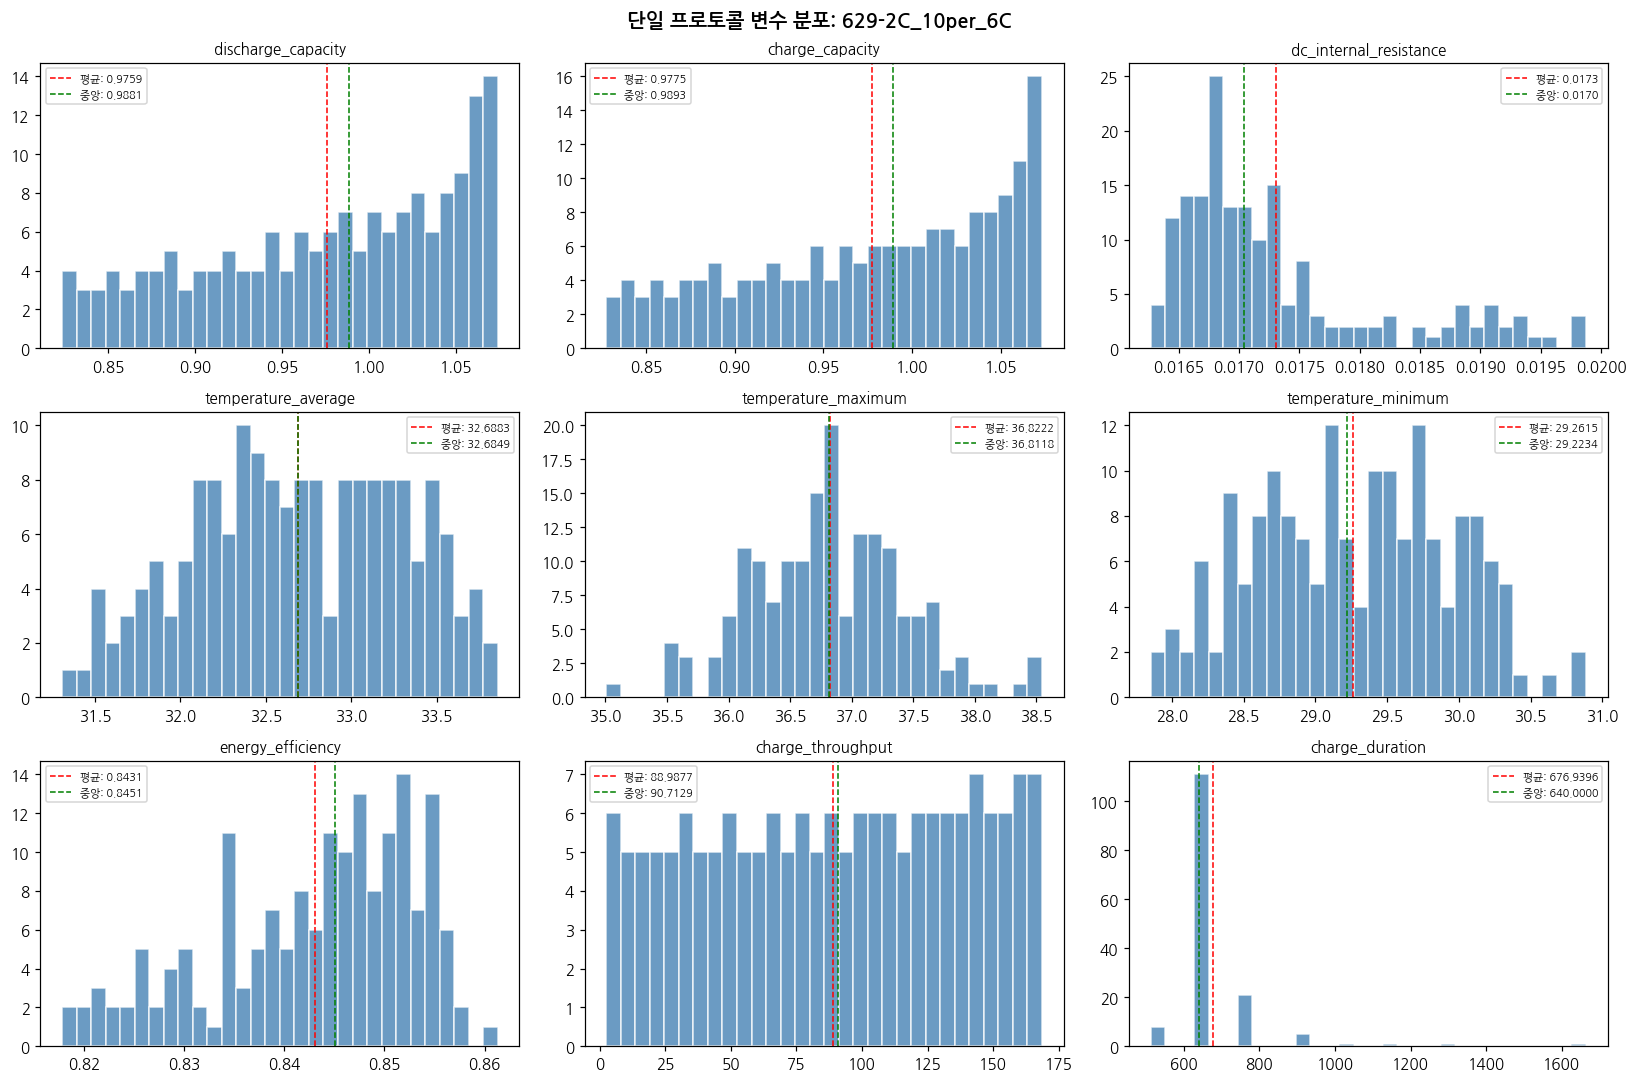

In [ ]:
# ════════════════════════════════════════════════════════
# [조절 가능 — 어떤 프로토콜로 분석할지 선택]
# ────────────────────────────────────────────────────────
SINGLE_PROTO = SHORTEST_PROTO   # 또는 LONGEST_PROTO, 다른 프로토콜
# ════════════════════════════════════════════════════════

sub_df = df_clean[df_clean['protocol'] == SINGLE_PROTO]

num_cols = ['discharge_capacity', 'charge_capacity',
            'dc_internal_resistance', 'temperature_average',
            'temperature_maximum', 'temperature_minimum',
            'energy_efficiency', 'charge_throughput',
            'charge_duration']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle(f'단일 프로토콜 변수 분포: {SINGLE_PROTO[-15:]}',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    data = sub_df[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1,
               label=f'평균: {data.mean():.4f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=1,
               label=f'중앙: {data.median():.4f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 04-2. 전체 데이터 변수 분포

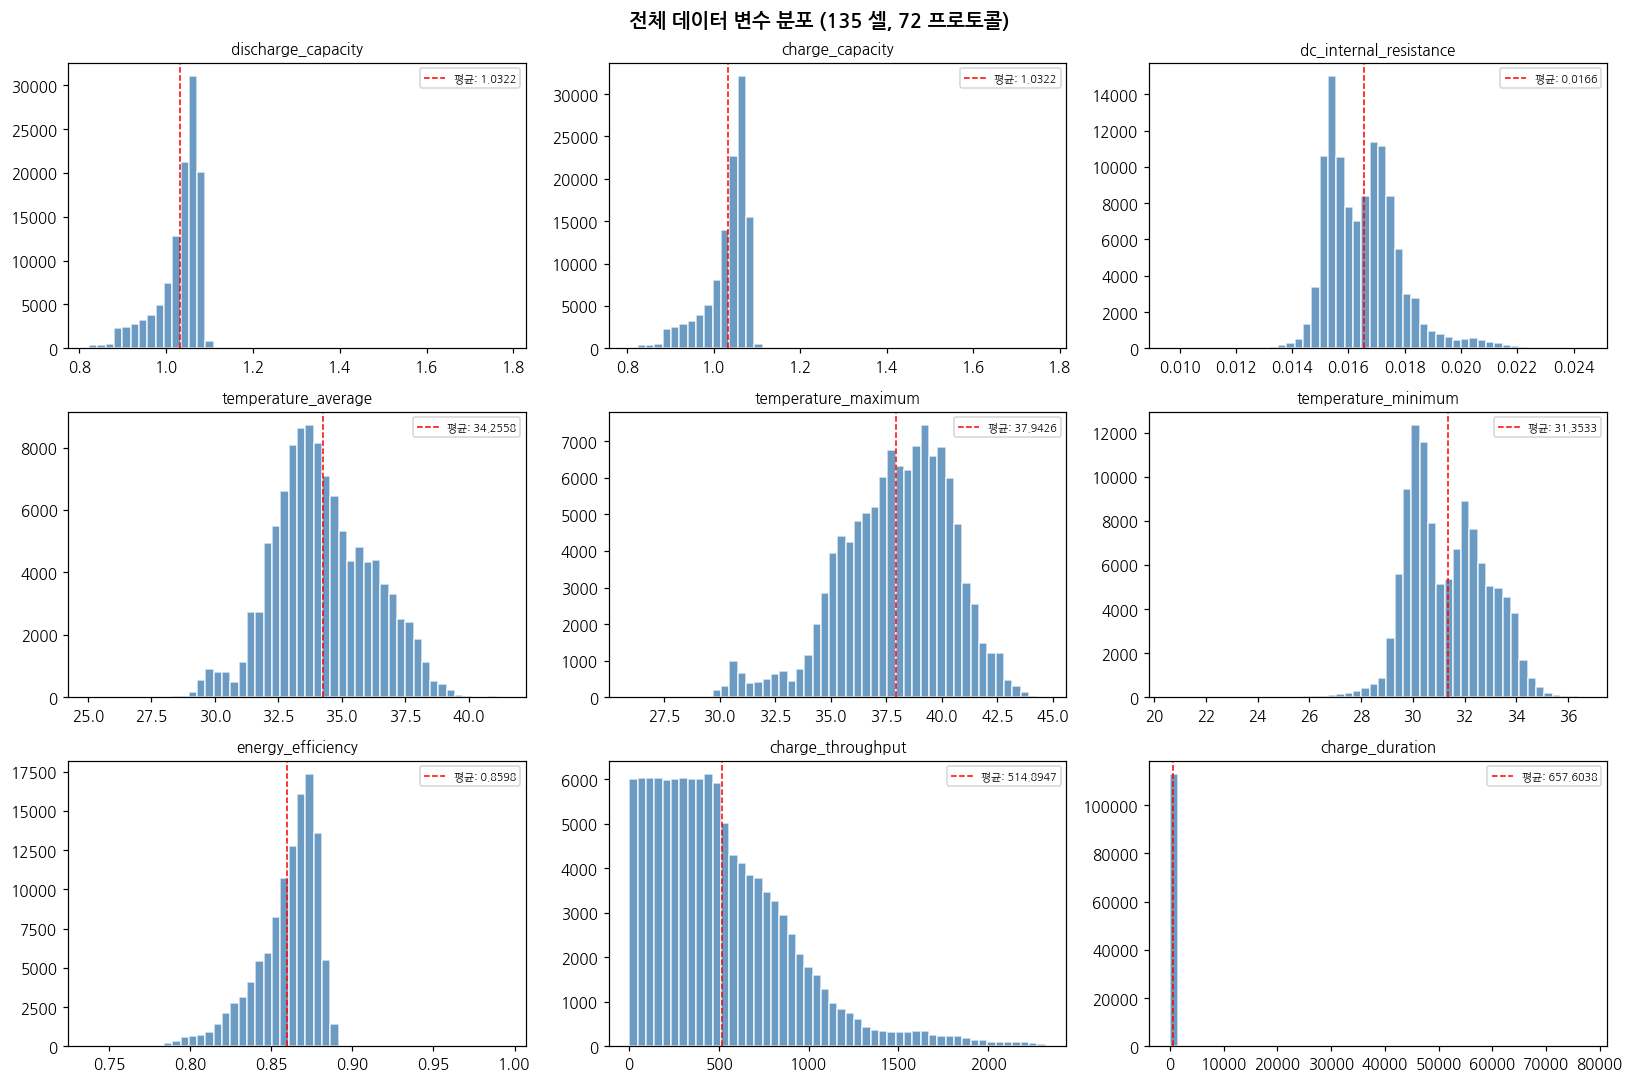

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('전체 데이터 변수 분포 (135 셀, 72 프로토콜)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    data = df_clean[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1,
               label=f'평균: {data.mean():.4f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 04-3. 변수 간 상관관계

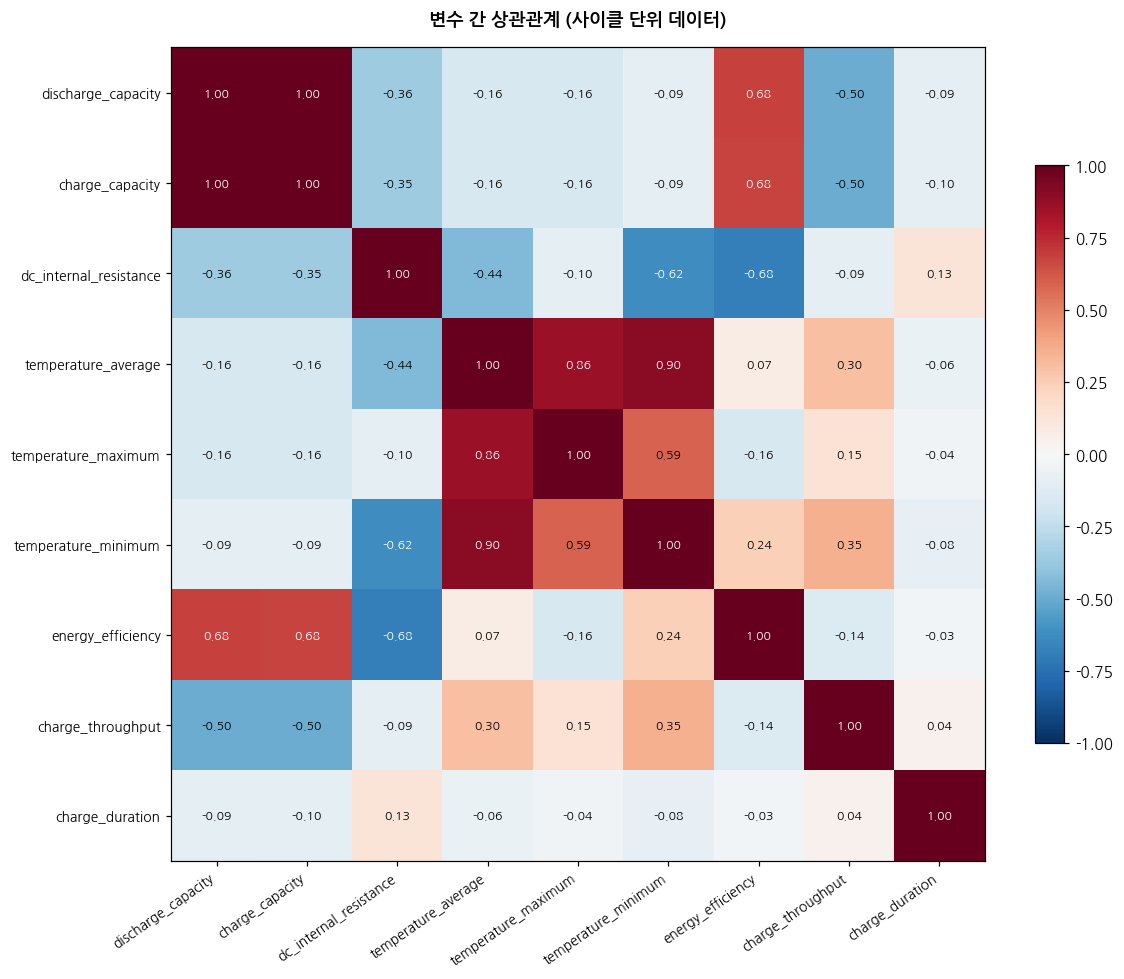

In [ ]:
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)

# 값 표시
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=color)

plt.colorbar(im, shrink=0.7)
ax.set_title('변수 간 상관관계 (사이클 단위 데이터)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 04-4. 다중공선성 (VIF)

VIF (Variance Inflation Factor):
- **VIF < 5**: 안전
- **5 ≤ VIF < 10**: 주의
- **VIF ≥ 10**: 심각한 다중공선성 → 모델링에서 제거 권장

VIF 결과:
 feature          VIF
eff_mean 26073.085903
 Qd_mean 19944.039345
  T_mean  5763.586722
   T_max  2441.817322
 IR_mean   741.096513
dur_mean   155.288970
  Qd_std     3.843161
Qd_slope     1.798675
IR_slope     1.491319


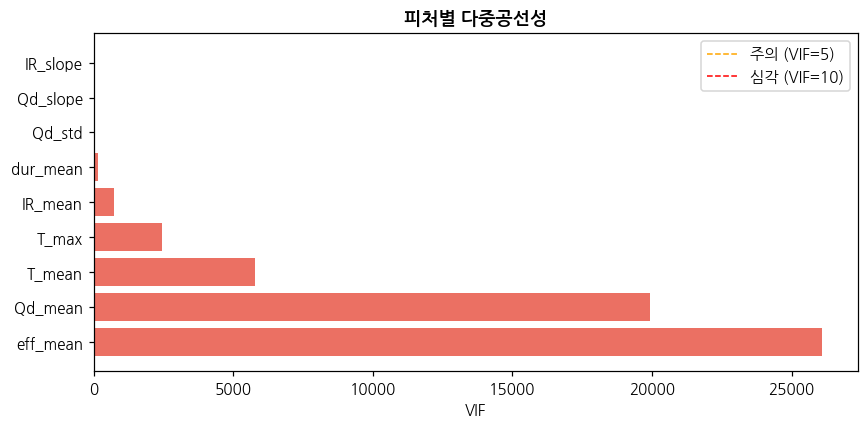

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 셀 수준 피처 집계 (초기 100사이클 기반)
N_EARLY = 100

def safe_polyfit_slope(x):
    x = x.dropna()
    if len(x) < 2:
        return np.nan
    return np.polyfit(range(len(x)), x.values, 1)[0]

cell_feat_dict = {}

for bc, g in df_clean.groupby('barcode'):
    g = g.sort_values('cycle_index').head(N_EARLY)
    cell_feat_dict[bc] = {
        'Qd_mean':  g['discharge_capacity'].mean(),
        'Qd_std':   g['discharge_capacity'].std(),
        'Qd_slope': safe_polyfit_slope(g['discharge_capacity']),
        'IR_mean':  g['dc_internal_resistance'].mean(),
        'IR_slope': safe_polyfit_slope(g['dc_internal_resistance']),
        'T_mean':   g['temperature_average'].mean(),
        'T_max':    g['temperature_maximum'].max(),
        'eff_mean': g['energy_efficiency'].mean(),
        'dur_mean': g['charge_duration'].mean(),
    }

cell_feat = pd.DataFrame(cell_feat_dict).T.dropna()

# VIF 계산
vif_data = pd.DataFrame()
vif_data['feature'] = cell_feat.columns
vif_data['VIF'] = [variance_inflation_factor(cell_feat.values, i)
                   for i in range(cell_feat.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("VIF 결과:")
print(vif_data.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
colors_vif = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#27ae60'
              for v in vif_data['VIF']]
ax.barh(vif_data['feature'], vif_data['VIF'], color=colors_vif, alpha=0.8)
ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='주의 (VIF=5)')
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='심각 (VIF=10)')
ax.set_xlabel('VIF')
ax.set_title('피처별 다중공선성', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 05. 수명 분포 분석

cycle_life는 우리의 타겟 변수 (Y)다. 그 분포를 자세히 봐야 모델 선택과 라벨 기준 설정이 가능하다.



## 05-1. cycle_life 셀별 정리 + 피처 결합

In [ ]:
# 03-1에서 만든 cell_life에 04-4에서 만든 피처 합치기
cell_life_full = cell_life.merge(
    cell_feat.reset_index().rename(columns={'index': 'barcode'}),
    on='barcode', how='left'
)

print(f"최종 데이터: {cell_life_full.shape}")
print(f"컬럼: {list(cell_life_full.columns)}")
print()
print(cell_life_full.head())

최종 데이터: (134, 12)
컬럼: ['barcode', 'cycle_life', 'protocol', 'Qd_mean', 'Qd_std', 'Qd_slope', 'IR_mean', 'IR_slope', 'T_mean', 'T_max', 'eff_mean', 'dur_mean']

          barcode  cycle_life                      protocol   Qd_mean  \
0  EL150800453113         718    20170512-5_4C-60PER_3C.SDU  1.067566   
1  EL150800453773         616    20170512-7C-40PER_3_6C.SDU  1.075746   
2  EL150800460433         890    20170512-6C-30PER_3_6C.SDU  1.082915   
3  EL150800460436         757      20170512-6C-60PER_3C.SDU  1.095432   
4  EL150800460468        1053  20170512-5_4C-40PER_3_6C.SDU  1.087638   

     Qd_std  Qd_slope   IR_mean      IR_slope     T_mean      T_max  eff_mean  \
0  0.001662  0.000034  0.016843  3.898176e-07  33.147990  38.476170  0.876424   
1  0.000853 -0.000006  0.016213  2.340326e-06  33.692927  37.995705  0.870921   
2  0.000985 -0.000003  0.016594  1.045125e-06  32.842317  37.758316  0.878249   
3  0.001113 -0.000018  0.016486  1.004633e-06  33.670448  38.728722  0.873286

## 05-2. 수명 분포 + 정규성 검정

/tmp/ipykernel_19280/31448994.py:44: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_19280/31448994.py:44: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


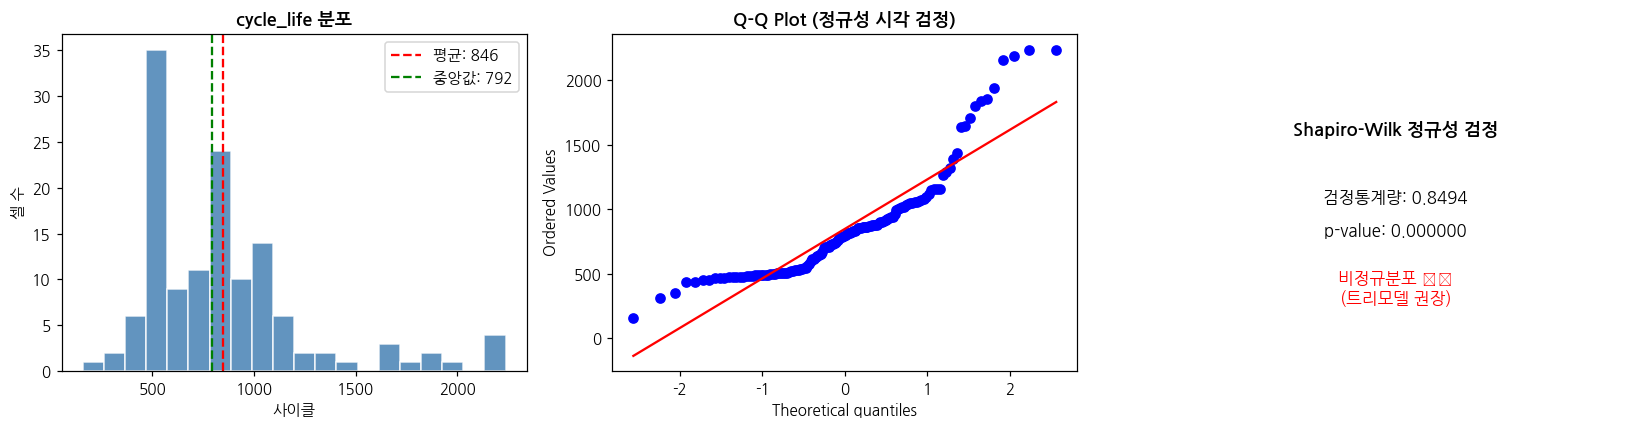

In [ ]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ① 히스토그램
ax = axes[0]
ax.hist(cell_life_full['cycle_life'], bins=20,
        color='steelblue', edgecolor='white', alpha=0.85)
mean_v = cell_life_full['cycle_life'].mean()
med_v  = cell_life_full['cycle_life'].median()
ax.axvline(mean_v, color='red', linestyle='--',
           linewidth=1.5, label=f"평균: {mean_v:.0f}")
ax.axvline(med_v, color='green', linestyle='--',
           linewidth=1.5, label=f"중앙값: {med_v:.0f}")
ax.set_title('cycle_life 분포', fontweight='bold')
ax.set_xlabel('사이클')
ax.set_ylabel('셀 수')
ax.legend()

# ② Q-Q Plot
ax = axes[1]
stats.probplot(cell_life_full['cycle_life'], dist="norm", plot=ax)
ax.set_title('Q-Q Plot (정규성 시각 검정)', fontweight='bold')

# ③ Shapiro-Wilk 검정
ax = axes[2]
stat, p_value = stats.shapiro(cell_life_full['cycle_life'])
ax.axis('off')
ax.text(0.5, 0.7, 'Shapiro-Wilk 정규성 검정',
        ha='center', fontsize=12, fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5, 0.5, f'검정통계량: {stat:.4f}', ha='center',
        fontsize=11, transform=ax.transAxes)
ax.text(0.5, 0.4, f'p-value: {p_value:.6f}', ha='center',
        fontsize=11, transform=ax.transAxes)

is_normal = p_value > 0.05
ax.text(0.5, 0.2,
        '정규분포 ✅\n(선형회귀 가능)' if is_normal else '비정규분포 ⚠️\n(트리모델 권장)',
        ha='center', fontsize=11,
        color='green' if is_normal else 'red',
        transform=ax.transAxes)

plt.tight_layout()
plt.show()

## 05-3. 프로토콜별 수명 박스플롯 (수명 짧→긺)

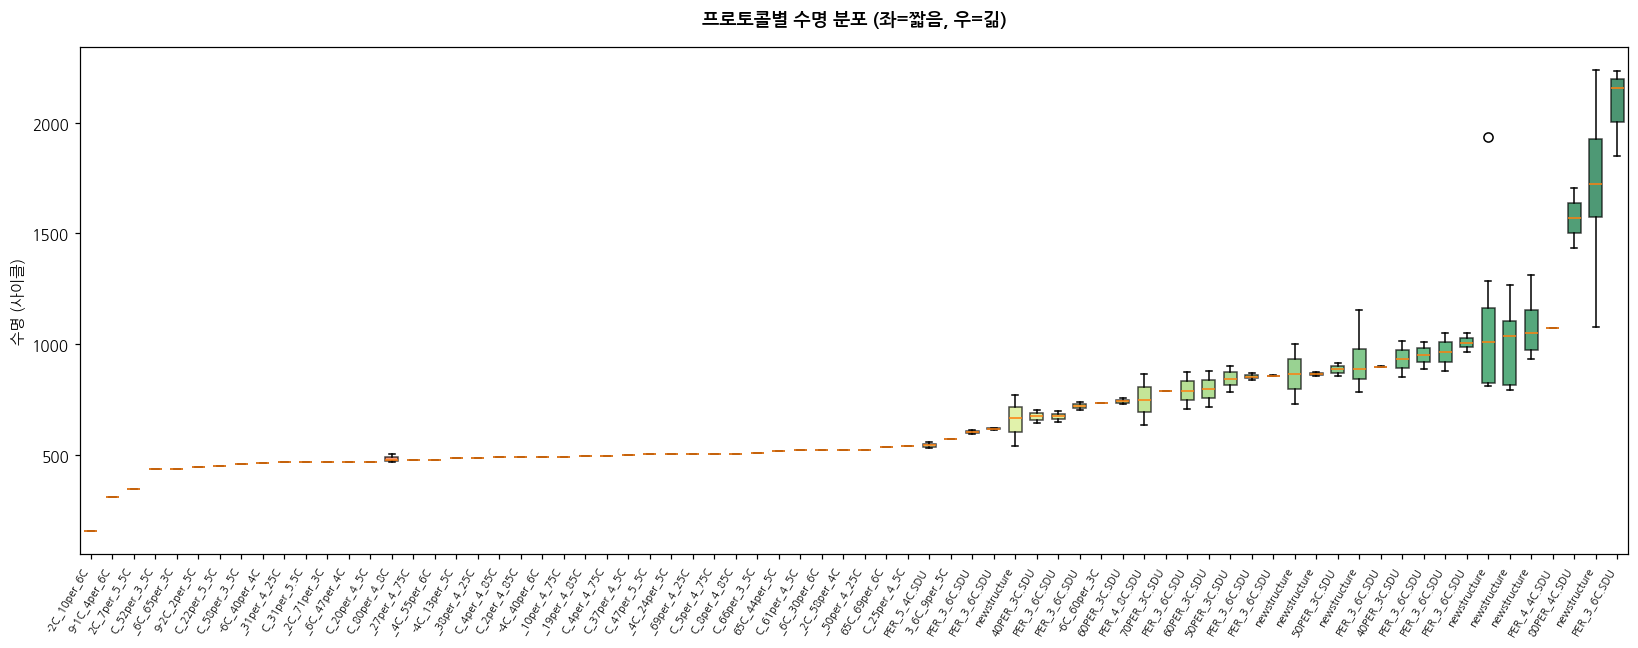

In [ ]:
proto_order = (cell_life_full.groupby('protocol')['cycle_life']
                              .median()
                              .sort_values()
                              .index)

fig, ax = plt.subplots(figsize=(15, 6))
data = [cell_life_full[cell_life_full['protocol']==p]['cycle_life'].values
        for p in proto_order]
bp = ax.boxplot(data, tick_labels=[p[-12:] for p in proto_order],
                patch_artist=True, widths=0.6)

# 색 그라데이션 (수명 짧→길)
n = len(data)
for i, patch in enumerate(bp['boxes']):
    ratio = i / max(n-1, 1)
    color = plt.cm.RdYlGn(ratio)
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.set_xticklabels([p[-12:] for p in proto_order],
                   rotation=60, ha='right', fontsize=7)
ax.set_ylabel('수명 (사이클)')
ax.set_title('프로토콜별 수명 분포 (좌=짧음, 우=긺)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 06. 라벨링 (양품/불량 + Grade)

수명을 기준으로 라벨을 직접 만든다. 임계값은 사용자가 조절 가능하다.

| 라벨 | 의미 |
|------|------|
| **불량** | 양품 기준 이하 → 시장 출하 불가 |
| **C Grade** | 양품 중 하위 → ESS/저가 EV |
| **B Grade** | 양품 중 중위 → 일반 EV |
| **A Grade** | 양품 중 상위 → 프리미엄 EV |



## 06-1. 양품/불량 분리 기준

양품/불량 기준: 500 사이클

분포:
is_good
1    108
0     26
Name: count, dtype: int64

양품 비율: 80.6%


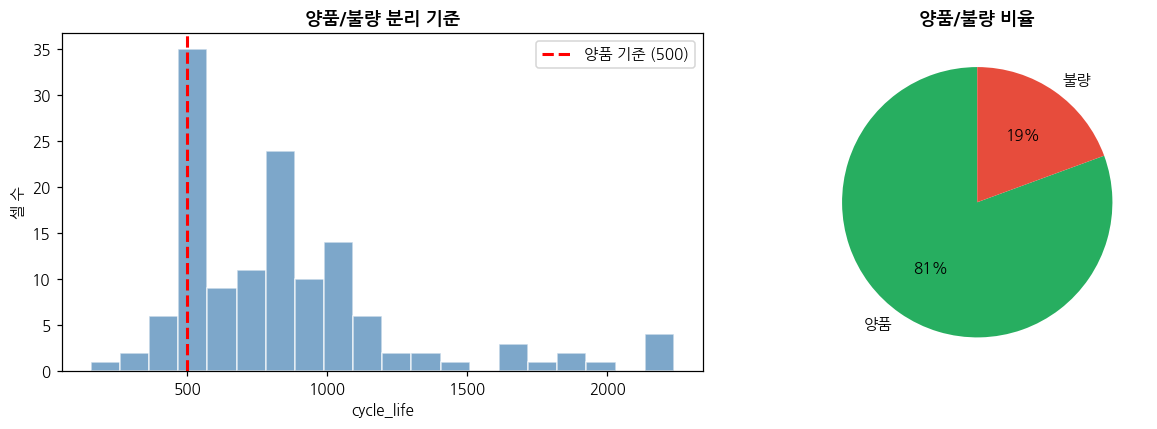

In [ ]:
# ════════════════════════════════════════════════════════
# [조절 가능 — 양품 임계값]
# ────────────────────────────────────────────────────────
GOOD_THRESHOLD = 500   # 이 사이클 이상 살면 양품
# ════════════════════════════════════════════════════════

cell_life_full['is_good'] = (cell_life_full['cycle_life'] >= GOOD_THRESHOLD).astype(int)

print(f"양품/불량 기준: {GOOD_THRESHOLD} 사이클")
print(f"\n분포:")
print(cell_life_full['is_good'].value_counts())
print(f"\n양품 비율: {cell_life_full['is_good'].mean() * 100:.1f}%")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(cell_life_full['cycle_life'], bins=20,
        color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(GOOD_THRESHOLD, color='red', linestyle='--',
           linewidth=2, label=f'양품 기준 ({GOOD_THRESHOLD})')
ax.set_xlabel('cycle_life')
ax.set_ylabel('셀 수')
ax.set_title('양품/불량 분리 기준', fontweight='bold')
ax.legend()

ax = axes[1]
counts = cell_life_full['is_good'].value_counts()
labels_pie = ['불량' if k==0 else '양품' for k in counts.index]
colors_pie = ['#e74c3c' if k==0 else '#27ae60' for k in counts.index]
ax.pie(counts.values, labels=labels_pie, colors=colors_pie,
       autopct='%1.0f%%', startangle=90)
ax.set_title('양품/불량 비율', fontweight='bold')

plt.tight_layout()
plt.show()

## 06-2. A/B/C Grade 분리 기준 (양품 내 분류)

In [ ]:
# ════════════════════════════════════════════════════════
# [조절 가능 — Grade 임계값 (양품 내에서만 분류)]
# ────────────────────────────────────────────────────────
GRADE_A_MIN = 1200   # A Grade 최소 사이클 (≥ 1200 = A)
GRADE_B_MIN = 800    # B Grade 최소 사이클 (800 ~ 1200 = B)
                     #                     (500 ~ 800   = C, 양품 하위)
# ════════════════════════════════════════════════════════

def assign_grade(row):
    if row['is_good'] == 0:
        return '불량'
    elif row['cycle_life'] >= GRADE_A_MIN:
        return 'A'
    elif row['cycle_life'] >= GRADE_B_MIN:
        return 'B'
    else:
        return 'C'

cell_life_full['grade'] = cell_life_full.apply(assign_grade, axis=1)

print("Grade 기준:")
print(f"  A:    ≥ {GRADE_A_MIN} 사이클")
print(f"  B:    {GRADE_B_MIN} ~ {GRADE_A_MIN-1} 사이클")
print(f"  C:    {GOOD_THRESHOLD} ~ {GRADE_B_MIN-1} 사이클")
print(f"  불량: < {GOOD_THRESHOLD} 사이클")
print(f"\nGrade 분포:")
print(cell_life_full['grade'].value_counts())

Grade 기준:
  A:    ≥ 1200 사이클
  B:    800 ~ 1199 사이클
  C:    500 ~ 799 사이클
  불량: < 500 사이클

Grade 분포:
grade
B     50
C     42
불량    26
A     16
Name: count, dtype: int64


## 06-3. Grade 분포 시각화 & 저장

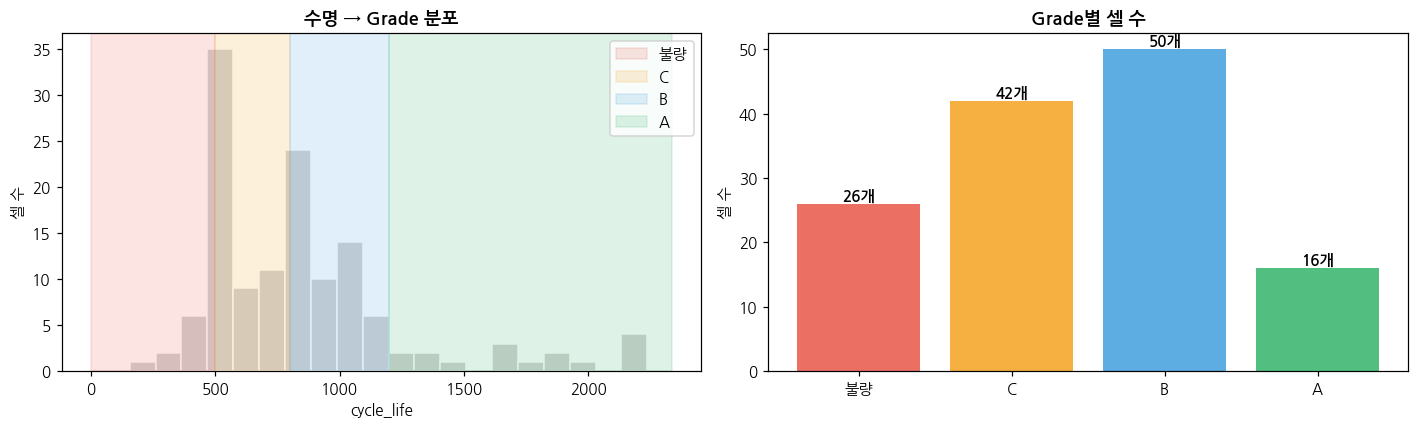


✅ 라벨 데이터 저장: /content/drive/MyDrive/battery_project/battery_cells_labeled.csv
   형태: (134, 14)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ① 수명 분포 위에 Grade 영역 표시
ax = axes[0]
ax.hist(cell_life_full['cycle_life'], bins=20,
        color='lightgray', edgecolor='white')
max_y = ax.get_ylim()[1]
ax.axvspan(0, GOOD_THRESHOLD, alpha=0.15, color='#e74c3c', label='불량')
ax.axvspan(GOOD_THRESHOLD, GRADE_B_MIN, alpha=0.15, color='#f39c12', label='C')
ax.axvspan(GRADE_B_MIN, GRADE_A_MIN, alpha=0.15, color='#3498db', label='B')
ax.axvspan(GRADE_A_MIN, cell_life_full['cycle_life'].max()+100,
           alpha=0.15, color='#27ae60', label='A')
ax.set_xlabel('cycle_life')
ax.set_ylabel('셀 수')
ax.set_title('수명 → Grade 분포', fontweight='bold')
ax.legend()

# ② Grade별 셀 수 막대
ax = axes[1]
grade_order = ['불량', 'C', 'B', 'A']
grade_counts = cell_life_full['grade'].value_counts().reindex(grade_order, fill_value=0)
colors_grade = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
bars = ax.bar(grade_order, grade_counts.values, color=colors_grade, alpha=0.8)
for bar, count in zip(bars, grade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{count}개', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('셀 수')
ax.set_title('Grade별 셀 수', fontweight='bold')

plt.tight_layout()
plt.show()

# 최종 라벨 저장
labeled_path = f'{PROJECT_DIR}/battery_cells_labeled.csv'
cell_life_full.to_csv(labeled_path, index=False)
print(f"\n✅ 라벨 데이터 저장: {labeled_path}")
print(f"   형태: {cell_life_full.shape}")

# 07. 모델링 추천

## 추천 모델: **XGBoost**

### 이 데이터에 XGBoost가 적합한 이유

| 데이터 특성 | XGBoost 적합성 |
|------------|--------------|
| 셀 수가 적음 (135개) | ✅ 적은 데이터에 강함 (딥러닝은 부적합) |
| 비정규 분포 (Shapiro-Wilk p < 0.05) | ✅ 분포 가정 없음 |
| 피처 간 비선형 관계 | ✅ 트리 모델이 자동 포착 |
| 다중공선성 일부 존재 | ✅ 영향 적음 (선형 모델은 취약) |
| 해석 필요 (SHAP) | ✅ TreeExplainer로 빠른 해석 |
| 발표용 비교 기준 필요 | ✅ Severson 논문(Elastic Net) 대비 가능 |

### 분석 단계별 모델

| 단계 | 문제 유형 | 모델 | 평가 지표 |
|------|---------|------|---------|
| **Step 1** | 양품/불량 분류 | XGBClassifier | F1, AUC, Confusion Matrix |
| **Step 2** | A/B/C Grade 분류 | XGBClassifier (다중) | Macro F1, Confusion Matrix |
| **Step 3** | cycle_life 회귀 (참고) | XGBRegressor | MAPE, R² |

### 비교 베이스라인

| 모델 | 용도 | 비고 |
|------|------|------|
| **Elastic Net** | 논문 재현 | Severson 2019의 baseline (MAPE 9.1%) |
| **Random Forest** | 트리 비교군 | 단일 트리보다 안정 |
| **XGBoost** | **메인 모델** | 위 둘 모두 능가 가능 |

### 교차검증 전략

- **K-Fold (k=5)**: 데이터가 적으니 5-Fold로 안정적 평가
- **Group K-Fold**: 같은 셀의 데이터가 train/test에 동시에 들어가지 않게 (이번엔 셀 단위 분석이라 불필요)
- **Stratified**: Grade 비율 유지

### SHAP 해석

- **TreeExplainer**: XGBoost 전용, 매우 빠름
- **결론 도출 예시**:
  - "ΔQ 분산이 X 이하면 → A Grade 확률 Y%"
  - "초기 내부저항이 Z 이상이면 → 불량 확률 W%"

---

## 다음 단계 코드 (별도 노트북에서 작성 예정)

1. 피처 엔지니어링 (논문 ΔQ 근사값 + 우리 추가 피처)
2. XGBoost 학습 (Step 1: 양품/불량)
3. XGBoost 학습 (Step 2: A/B/C Grade)
4. SHAP 해석
5. 비즈니스 가치 정량화 (재고비용 절감액)

#NEW 전처리

In [ ]:
import pandas as pd

# 1. 제공해주신 구글 드라이브 경로로 데이터 불러오기
file_path = '/content/drive/MyDrive/battery_project/battery_cycles_(3) (1).csv'
df = pd.read_csv(file_path)

# 2. 시계열 전처리를 위한 필수 작업: 정렬
# 바코드(셀)별로 먼저 묶고, 그 안에서 사이클(cycle_index) 순서대로 오름차순 정렬합니다.
# 인덱스를 재정렬하여 데이터 순서를 보장합니다.
df_sorted = df.sort_values(by=['barcode', 'cycle_index']).reset_index(drop=True)

# 3. 바코드(셀) 단위로 그룹화 객체 생성
grouped_cells = df_sorted.groupby('barcode')

# ==========================================
# [확인용 코드] 그룹화 결과 출력해보기
# ==========================================

# 데이터셋에 존재하는 전체 바코드(셀) 목록 확인
barcode_list = list(grouped_cells.groups.keys())
print(f"총 {len(barcode_list)}개의 배터리 셀 데이터가 분리되었습니다.")
print("확인된 바코드 일부:", barcode_list[:3], "...")

# 첫 번째 바코드 셀의 데이터를 추출하여 순서대로 잘 묶였는지 확인
first_cell_id = barcode_list[0]
first_cell_data = grouped_cells.get_group(first_cell_id)

print(f"\n--- [{first_cell_id}] 셀의 상위 5개 사이클 데이터 ---")
print(first_cell_data[['barcode', 'cycle_index', 'discharge_capacity', 'dc_internal_resistance']].head())

총 135개의 배터리 셀 데이터가 분리되었습니다.
확인된 바코드 일부: ['EL150800453113', 'EL150800453773', 'EL150800460433'] ...

--- [EL150800453113] 셀의 상위 5개 사이클 데이터 ---
          barcode  cycle_index  discharge_capacity  dc_internal_resistance
0  EL150800453113            0            1.656644                0.017469
1  EL150800453113            1            1.058599                0.017123
2  EL150800453113            2            1.061124                0.017168
3  EL150800453113            3            1.062743                0.017166
4  EL150800453113            4            1.063727                0.017137


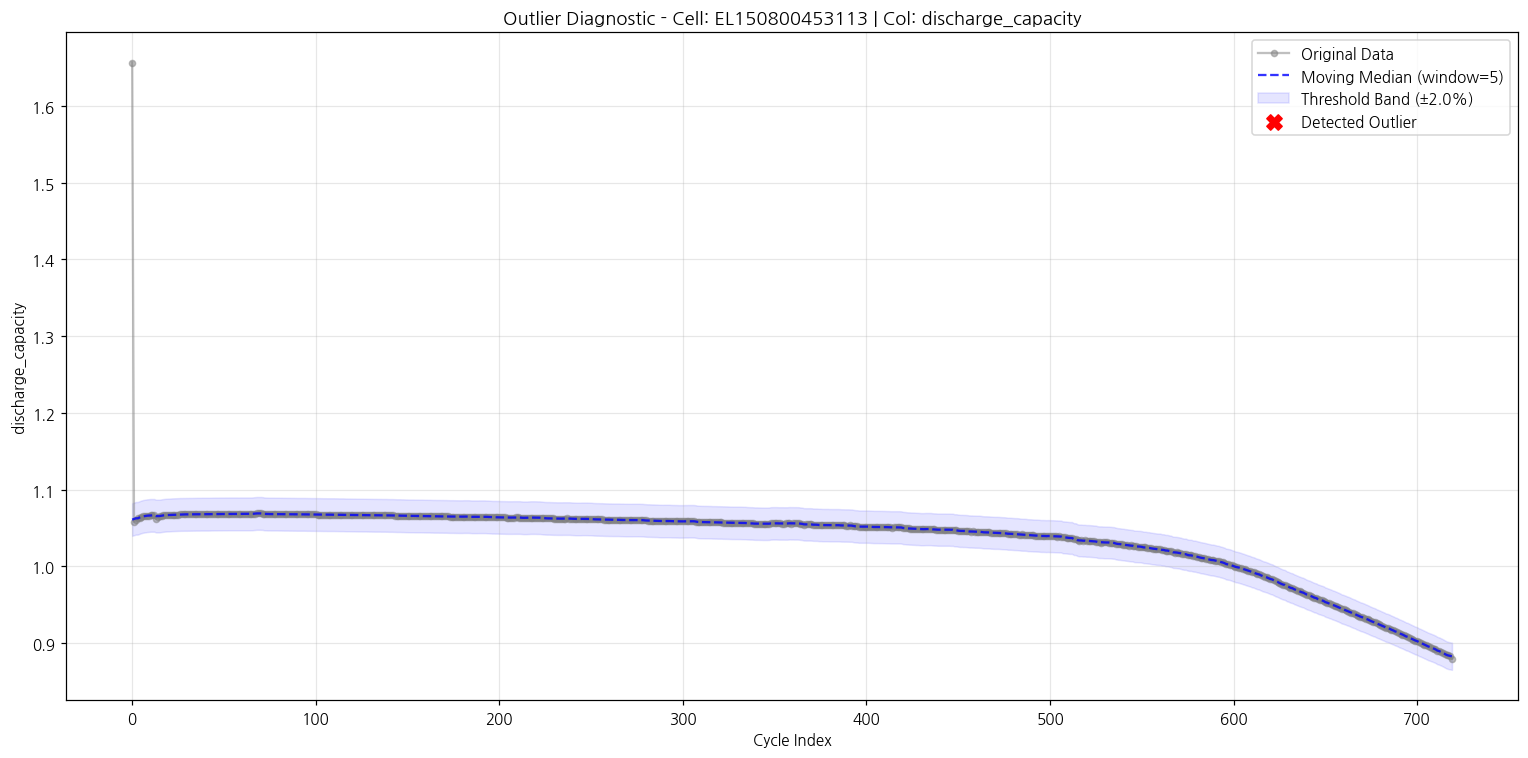

총 0개의 이상치 후보가 발견되었습니다.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def inspect_outliers(df, barcode, target_col='discharge_capacity', window=5, threshold=0.02):
    """
    특정 배터리 셀의 데이터를 시각화하여 이상치 판별 기준을 진단하는 함수
    데이터를 수정(삭제)하지 않고 보여주기만 합니다.
    """
    # 1. 진단할 특정 셀 데이터만 추출 후 정렬
    cell_data = df[df['barcode'] == barcode].copy()
    cell_data = cell_data.sort_values('cycle_index').reset_index(drop=True)

    # 2. 기준선(이동 중앙값)과 허용 오차 밴드(상/하한선) 계산
    rolling_med = cell_data[target_col].rolling(window=window, center=True, min_periods=1).median()
    upper_bound = rolling_med * (1 + threshold)
    lower_bound = rolling_med * (1 - threshold)

    # 3. 로직이 생각하는 '이상치 후보' 찾기
    error_ratio = np.abs(cell_data[target_col] - rolling_med) / rolling_med
    is_large_error = error_ratio > threshold

    diff_prev = cell_data[target_col] - cell_data[target_col].shift(1)
    diff_next = cell_data[target_col] - cell_data[target_col].shift(-1)
    is_peak_or_valley = (diff_prev * diff_next) > 0

    # 최종 이상치 후보 마스크
    outlier_candidates = is_large_error & is_peak_or_valley

    # ==========================================
    # 4. 진단 그래프 그리기
    # ==========================================
    plt.figure(figsize=(14, 7))

    # ① 원본 데이터 (회색 선/점)
    plt.plot(cell_data['cycle_index'], cell_data[target_col],
             marker='o', markersize=4, color='gray', alpha=0.5, label='Original Data')

    # ② 기준선: 이동 중앙값 (파란 점선)
    plt.plot(cell_data['cycle_index'], rolling_med,
             color='blue', linestyle='--', alpha=0.8, label=f'Moving Median (window={window})')

    # ③ 허용 오차 밴드 (파란색 반투명 영역)
    plt.fill_between(cell_data['cycle_index'], lower_bound, upper_bound,
                     color='blue', alpha=0.1, label=f'Threshold Band (±{threshold*100}%)')

    # ④ 로직이 잡은 이상치 후보 (빨간색 ❌ 마커)
    plt.scatter(cell_data.loc[outlier_candidates, 'cycle_index'],
                cell_data.loc[outlier_candidates, target_col],
                color='red', s=100, zorder=5, marker='X', label='Detected Outlier')

    plt.title(f'Outlier Diagnostic - Cell: {barcode} | Col: {target_col}')
    plt.xlabel('Cycle Index')
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 로직이 잡은 이상치들의 실제 값 출력
    print(f"총 {outlier_candidates.sum()}개의 이상치 후보가 발견되었습니다.")
    return cell_data[outlier_candidates][['cycle_index', target_col]]

# --- [사용 예시] ---
# df_sorted는 이전 단계에서 만든 정렬된 원본 데이터프레임입니다.
# 사진에서 문제가 된 바코드(셀 이름)를 복사해서 아래에 넣어주세요.
problem_barcode = df_sorted['barcode'].unique()[0] # 임시로 첫 번째 셀 지정

# 함수 실행 (파라미터를 바꿔가며 테스트해 볼 수 있습니다)
suspects_df = inspect_outliers(df_sorted, problem_barcode, target_col='discharge_capacity', window=5, threshold=0.02)

#EDA

/tmp/ipykernel_19280/2414901278.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


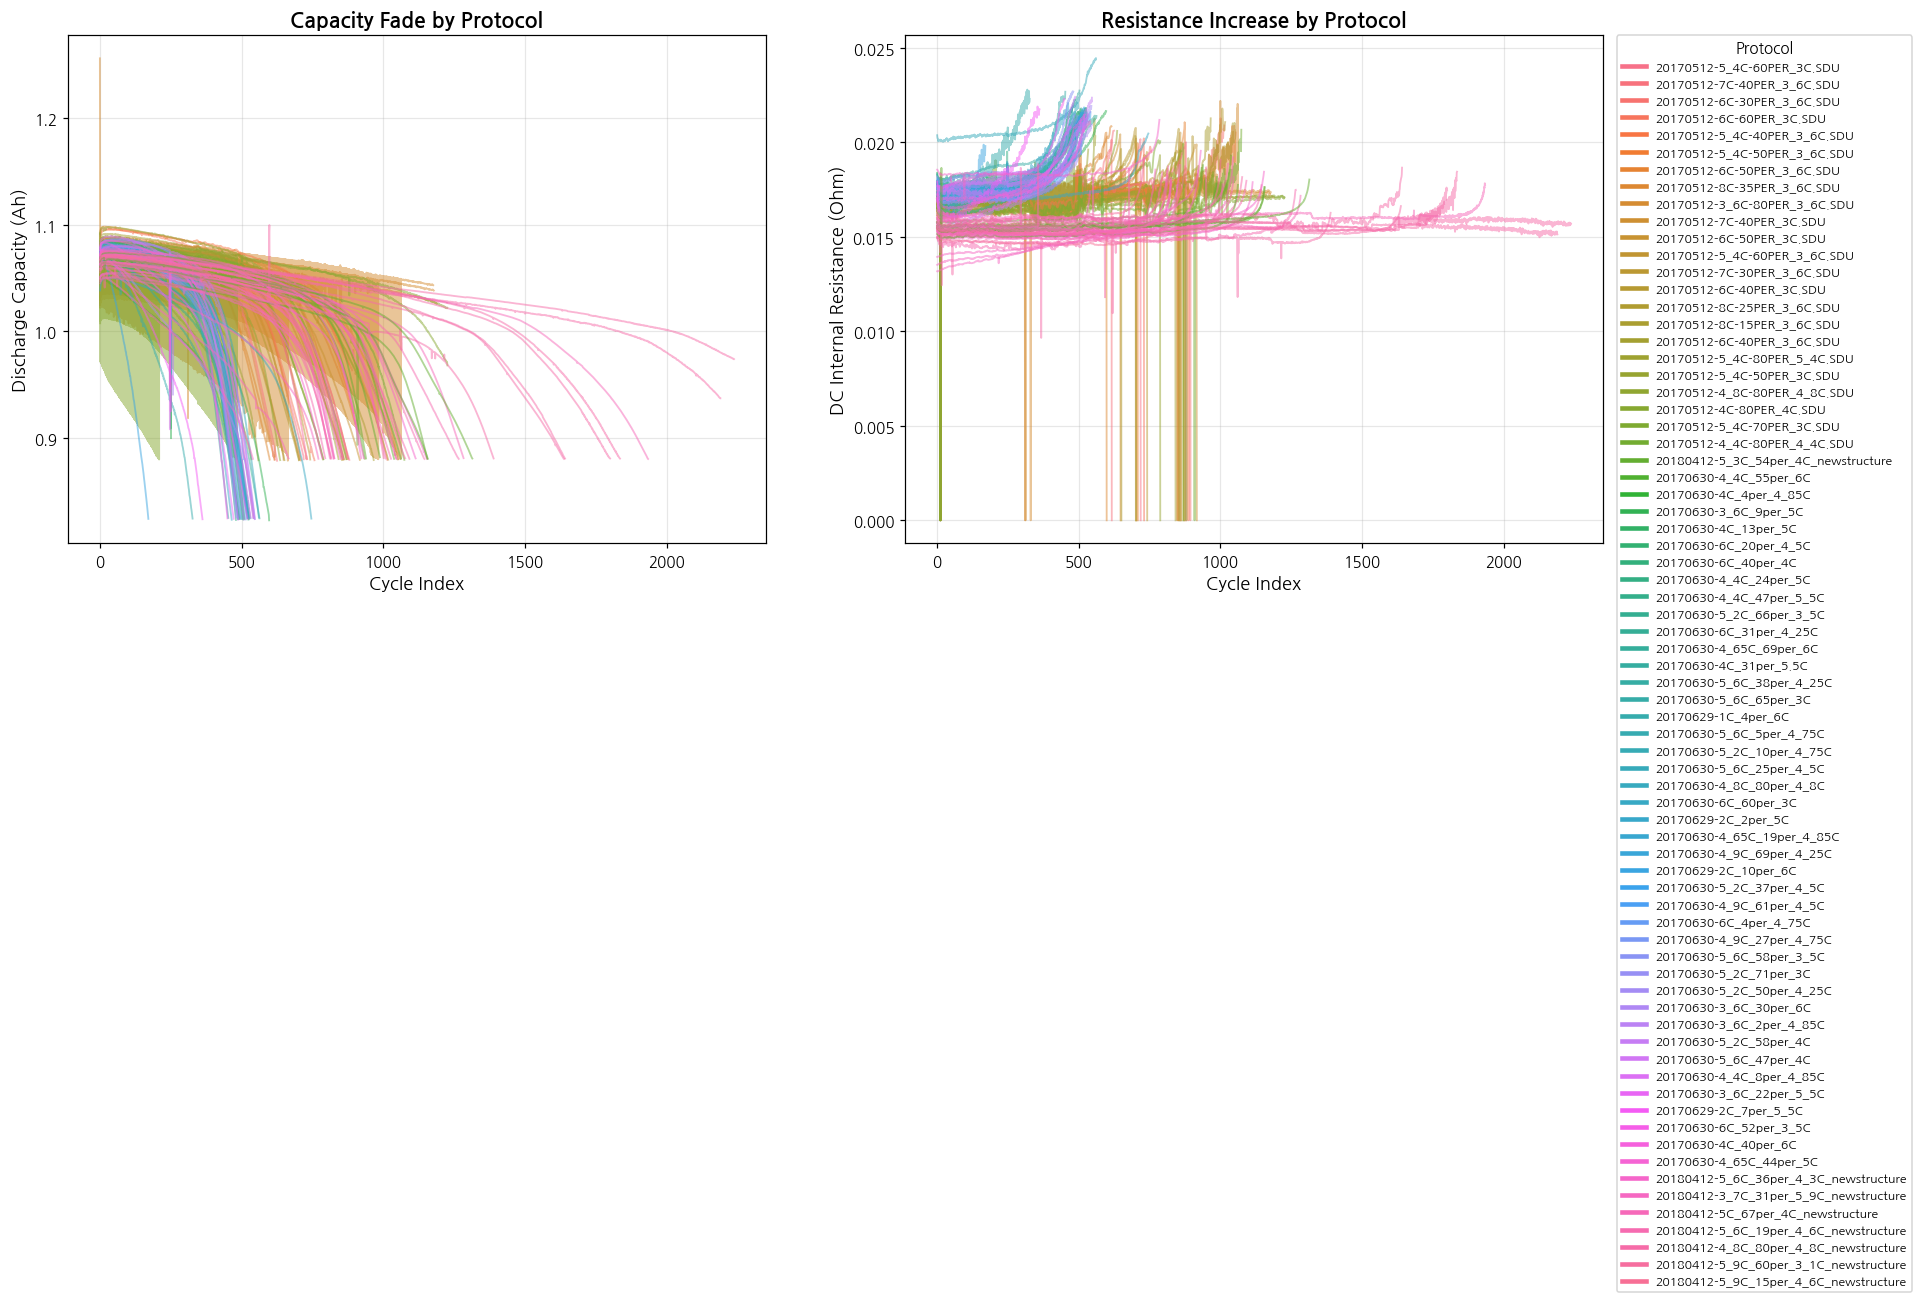

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. 1.3Ah 초과 이상치(초기 검사 데이터) 제거
df_filtered = df_sorted[df_sorted['discharge_capacity'] <= 1.3].copy()

# 프로토콜 종류 및 색상 지정
protocols = df_filtered['protocol'].unique()
colors = sns.color_palette("husl", len(protocols))
color_map = dict(zip(protocols, colors))

# 2. 도화지 설정 (범례가 들어갈 오른쪽 공간을 확보하기 위해 가로 길이를 18로 더 늘림)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

grouped = df_filtered.groupby('barcode')

for barcode, group in grouped:
    cell_protocol = group['protocol'].iloc[0]
    c = color_map[cell_protocol]

    # 선 그래프 그리기
    axes[0].plot(group['cycle_index'], group['discharge_capacity'],
                 color=c, alpha=0.5, linewidth=1.2)
    axes[1].plot(group['cycle_index'], group['dc_internal_resistance'],
                 color=c, alpha=0.5, linewidth=1.2)

# 3. 범례(Legend) 만들기
legend_elements = [Line2D([0], [0], color=color_map[p], lw=3, label=p) for p in protocols]

# [그래프 1] 용량 감소 설정
axes[0].set_title('Capacity Fade by Protocol', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cycle Index', fontsize=12)
axes[0].set_ylabel('Discharge Capacity (Ah)', fontsize=12)
axes[0].grid(True, alpha=0.3)
# 🌟 왼쪽 그래프는 범례 표시 코드를 아예 삭제했습니다.

# [그래프 2] 저항 증가 설정
axes[1].set_title('Resistance Increase by Protocol', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cycle Index', fontsize=12)
axes[1].set_ylabel('DC Internal Resistance (Ohm)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 🌟 [핵심] 범례를 오른쪽 그래프의 바깥쪽(bbox_to_anchor)으로 완전히 빼냅니다.
axes[1].legend(handles=legend_elements, title='Protocol',
               bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=8, borderaxespad=0.)

# 그래프와 바깥쪽 범례가 잘리지 않도록 레이아웃 자동 조절
plt.tight_layout()
plt.show()

##가설1:충방전 속도가 빠르면 열화 가속화(용량과 내부저항)

/tmp/ipykernel_19280/2855333467.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


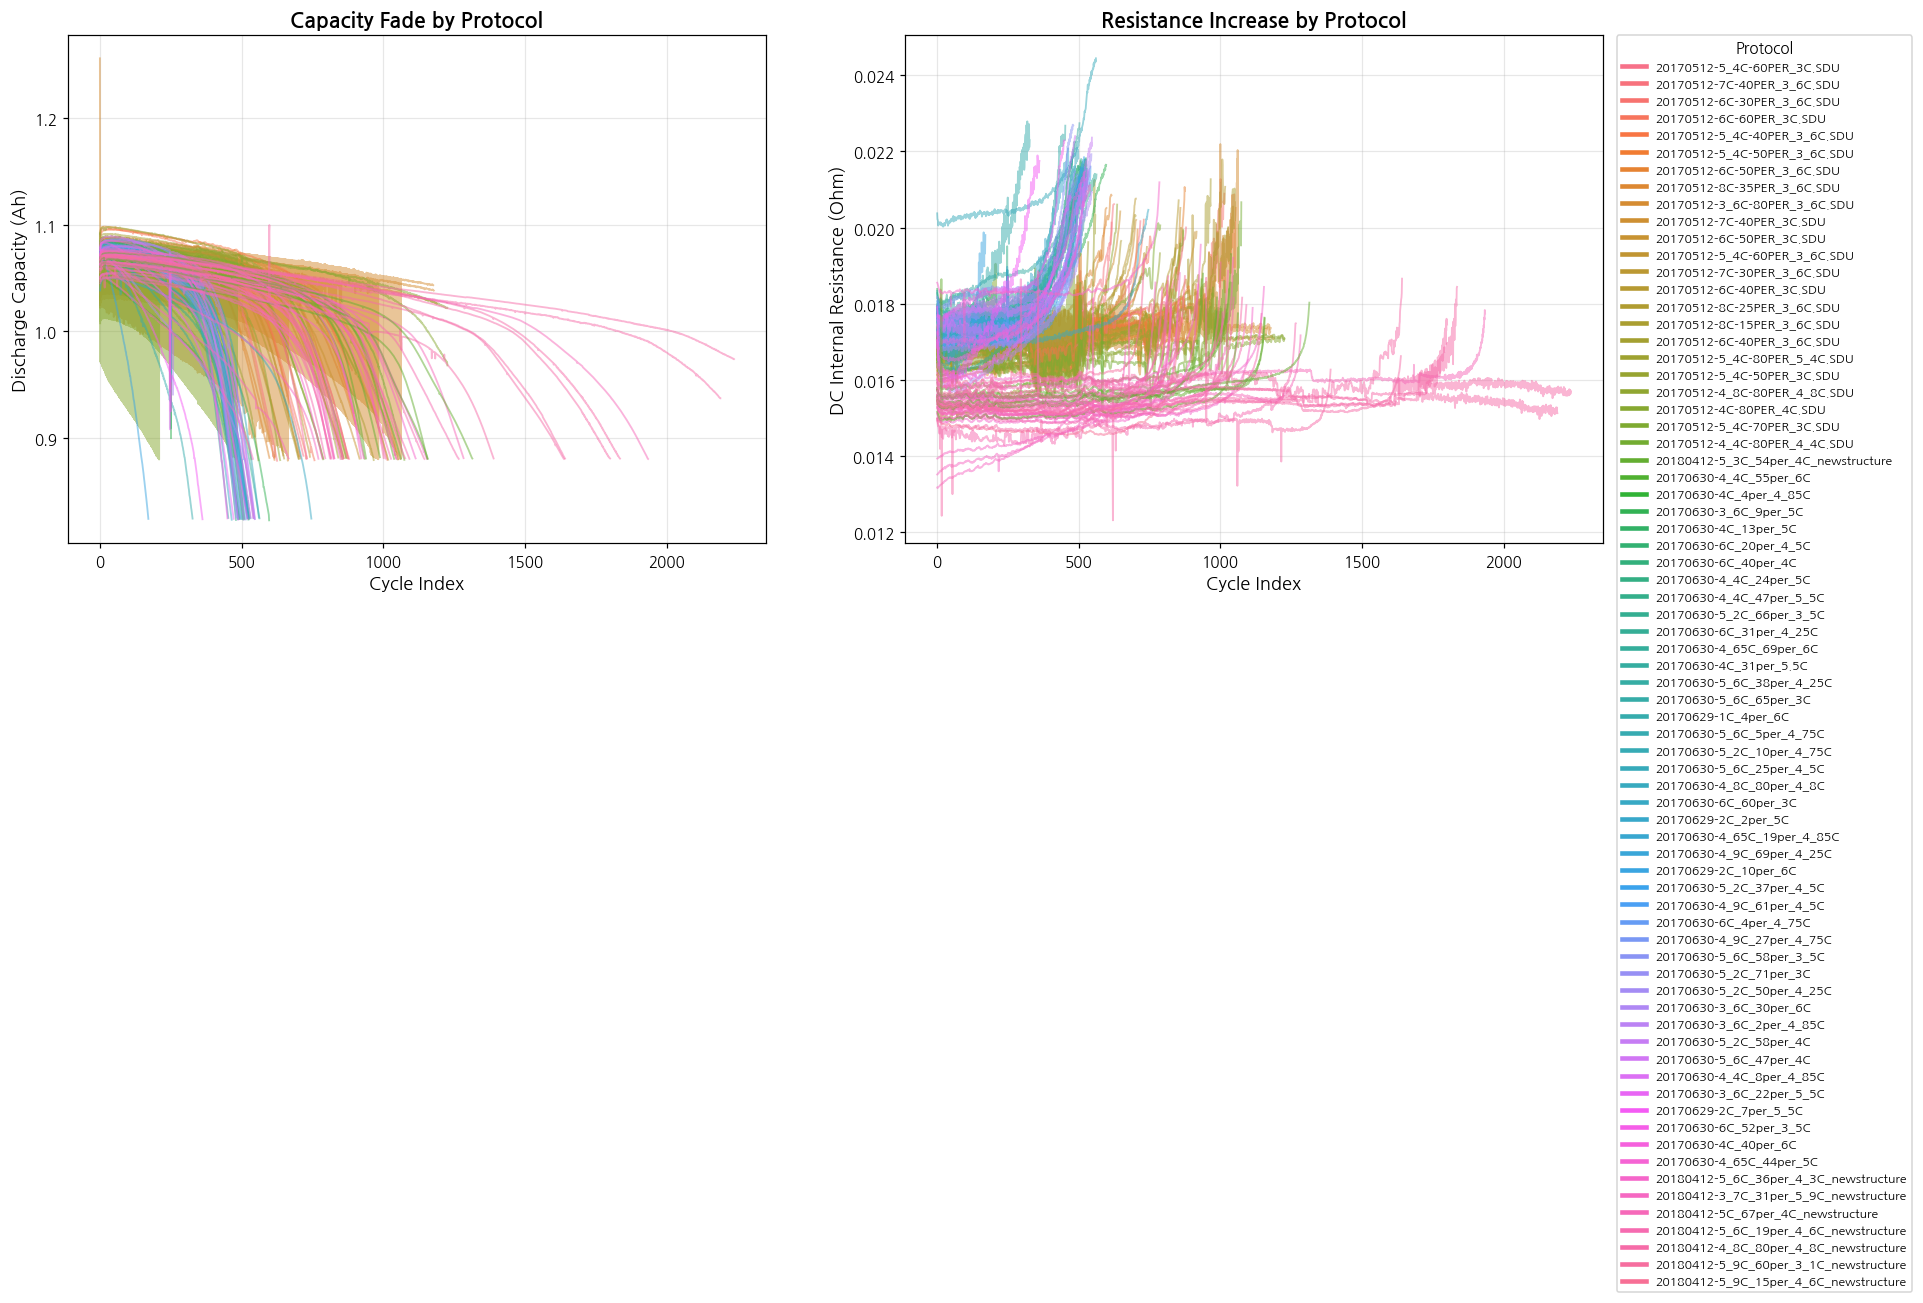

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. [핵심 전처리] 용량과 저항의 초기 이상치 동시 제거
# discharge_capacity가 1.3 이하 '이고(&)', dc_internal_resistance가 0.012 초과인 정상 데이터만 남깁니다.
df_filtered = df_sorted[
    (df_sorted['discharge_capacity'] <= 1.3) &
    (df_sorted['dc_internal_resistance'] > 0.012)
].copy()

# 프로토콜 종류 및 색상 지정
protocols = df_filtered['protocol'].unique()
colors = sns.color_palette("husl", len(protocols))
color_map = dict(zip(protocols, colors))

# 2. 도화지 설정 (가로 18, 세로 6)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

grouped = df_filtered.groupby('barcode')

for barcode, group in grouped:
    cell_protocol = group['protocol'].iloc[0]
    c = color_map[cell_protocol]

    # 선 그래프 그리기
    axes[0].plot(group['cycle_index'], group['discharge_capacity'],
                 color=c, alpha=0.5, linewidth=1.2)
    axes[1].plot(group['cycle_index'], group['dc_internal_resistance'],
                 color=c, alpha=0.5, linewidth=1.2)

# 3. 범례(Legend) 만들기
legend_elements = [Line2D([0], [0], color=color_map[p], lw=3, label=p) for p in protocols]

# [그래프 1] 용량 감소 설정
axes[0].set_title('Capacity Fade by Protocol', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cycle Index', fontsize=12)
axes[0].set_ylabel('Discharge Capacity (Ah)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# [그래프 2] 저항 증가 설정
axes[1].set_title('Resistance Increase by Protocol', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cycle Index', fontsize=12)
axes[1].set_ylabel('DC Internal Resistance (Ohm)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 범례를 오른쪽 그래프의 우측 바깥으로 배치
axes[1].legend(handles=legend_elements, title='Protocol',
               bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=8, borderaxespad=0.)

# 레이아웃 자동 조절 및 출력
plt.tight_layout()
plt.show()

1. 방전 용량 그래프 해석 (Capacity Fade)
왼쪽 그래프를 보시면 선들의 무리가 크게 두 그룹으로 나뉘는 것을 볼 수 있습니다.

완만한 궤적 (저속 충전): X축을 따라 1000회~1200회 사이클 이상까지 완만하게 우하향하며 길게 뻗어나가는 선들이 있습니다. 이는 1C, 2C 등 상대적으로 충전 속도가 느린 부드러운 프로토콜들입니다.

급격한 추락 (고속 충전): 반면, 400회~600회 부근에서 용량이 절벽처럼 뚝 떨어지는 형태(Knee Point)를 그리는 선들이 뚜렷하게 보입니다. 범례에서 6C, 7C, 8C처럼 가혹한 급속 충전 조건일수록 이렇게 이른 시기에 수명이 곤두박질치는 양상을 보입니다.

2. 내부 저항 그래프 해석 (Power Fade)
오른쪽 그래프는 용량 감소의 '원인'을 시각적으로 뒷받침해 줍니다.

용량이 급감하는 바로 그 시점(Knee Point)에 맞춰, 해당 셀들의 내부 저항이 위로 폭발적으로 치솟는 것을 확인할 수 있습니다.

충전 속도(전류량)가 높을수록 옴의 법칙에 따른 극심한 내부 발열이 발생하고, 리튬 이온이 음극에 제대로 안착하지 못해 표면에 석출되는 현상(Lithium Plating)이 가속화됩니다. 결국 이로 인해 전자의 흐름을 방해하는 저항이 급증하여 배터리가 출력을 내지 못하고 사망에 이르는 물리적 메커니즘이 데이터로 완벽하게 나타난 것입니다.

/tmp/ipykernel_19280/2705768036.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


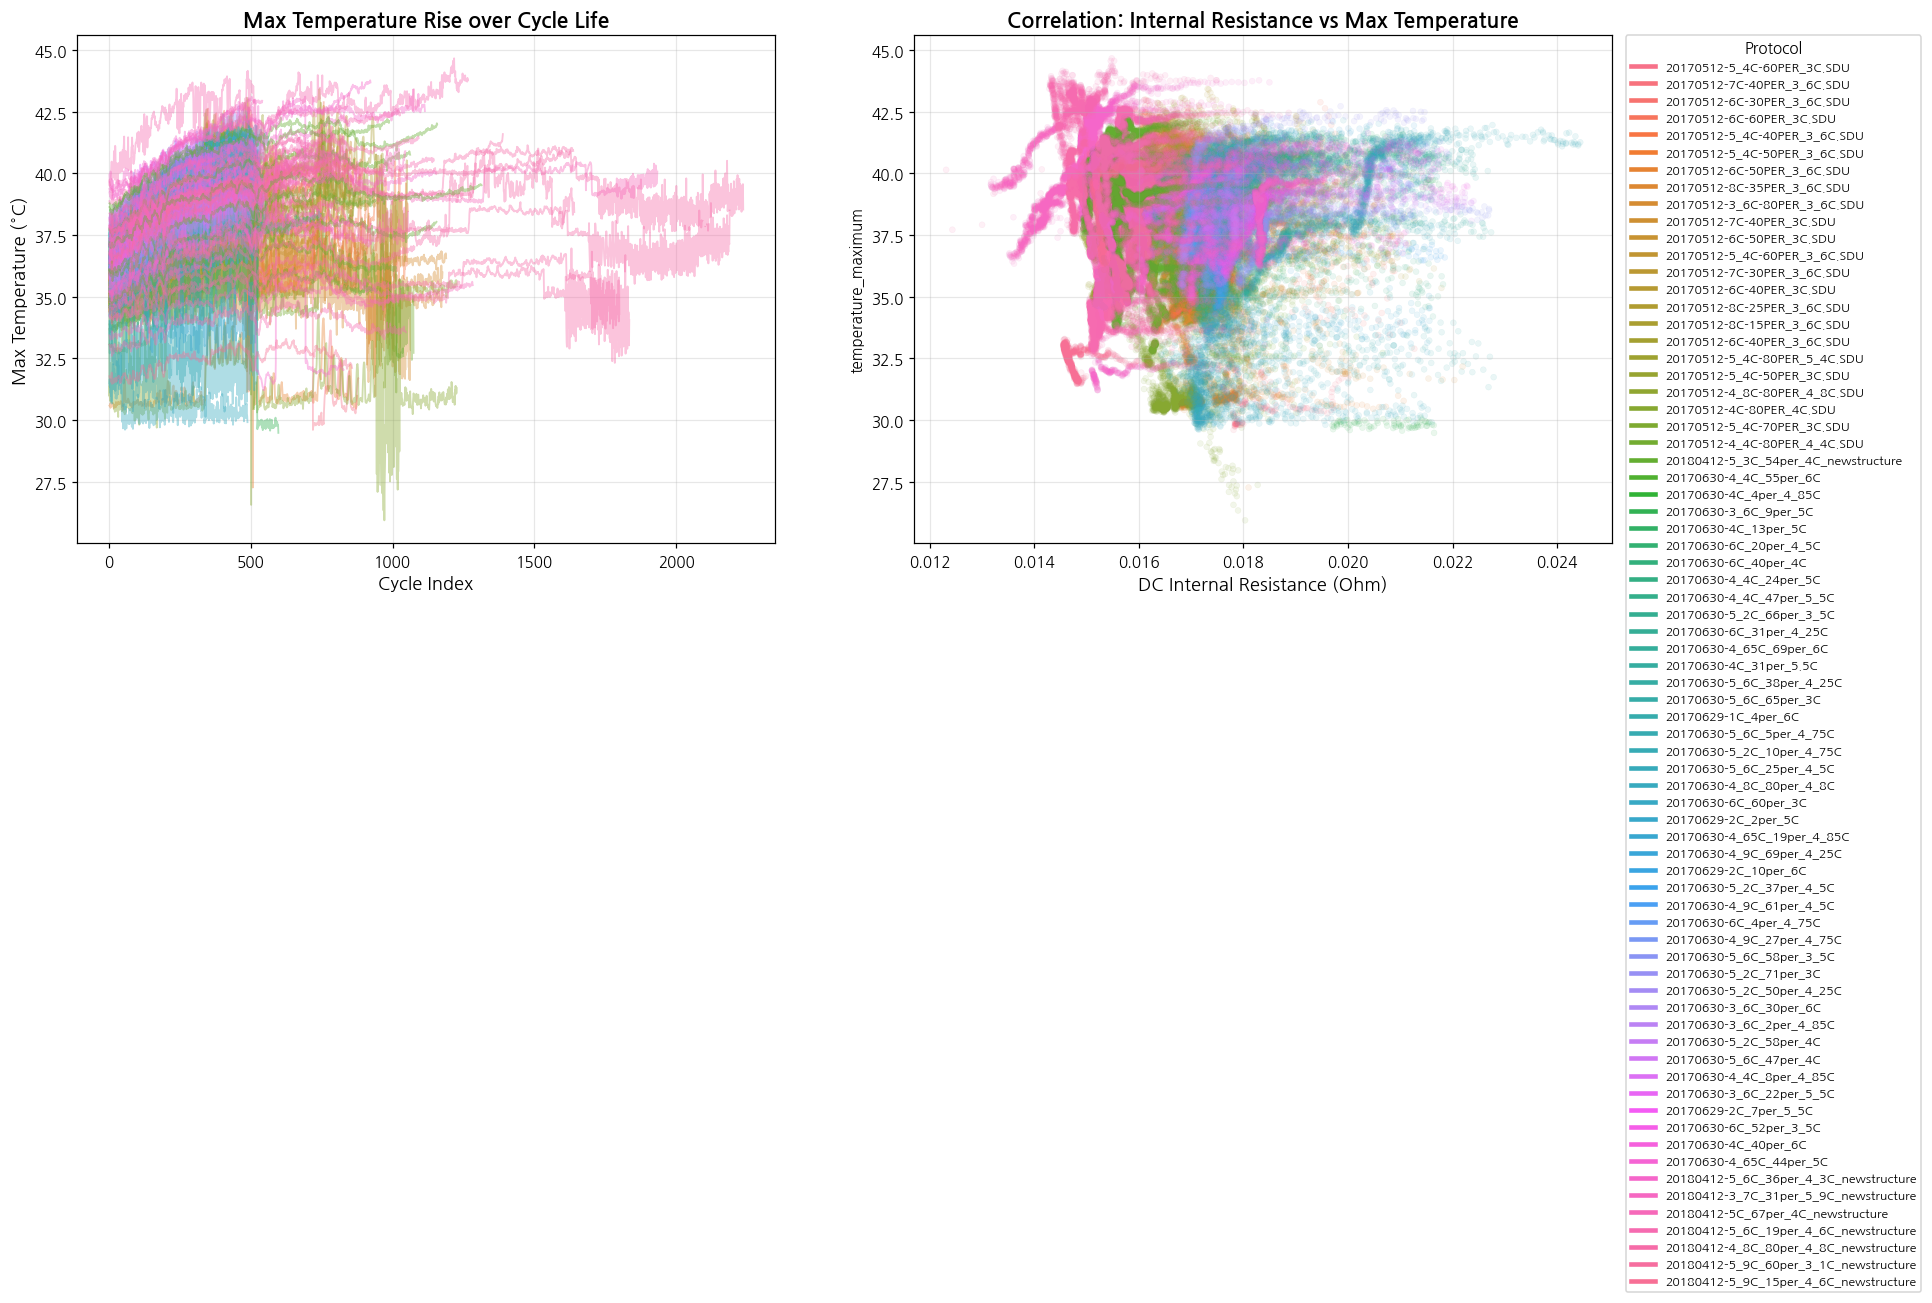

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. 이상치 제거 (이전과 동일한 조건: 용량 <= 1.3 & 저항 > 0.012)
df_filtered = df_sorted[
    (df_sorted['discharge_capacity'] <= 1.3) &
    (df_sorted['dc_internal_resistance'] > 0.012)
].copy()

# 온도 센서 노이즈(예: 0도 또는 100도 이상으로 잘못 찍힌 값) 필터링
df_filtered = df_filtered[
    (df_filtered['temperature_maximum'] > 20) &
    (df_filtered['temperature_maximum'] < 60)
]

# 프로토콜 종류 및 색상 지정
protocols = df_filtered['protocol'].unique()
colors = sns.color_palette("husl", len(protocols))
color_map = dict(zip(protocols, colors))

# 2. 도화지 설정 (가로 18, 세로 6)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

grouped = df_filtered.groupby('barcode')

# ---------------------------------------------------
# [그래프 1] 수명(사이클)에 따른 최고 온도 변화 (선 그래프)
# ---------------------------------------------------
for barcode, group in grouped:
    cell_protocol = group['protocol'].iloc[0]
    c = color_map[cell_protocol]

    axes[0].plot(group['cycle_index'], group['temperature_maximum'],
                 color=c, alpha=0.4, linewidth=1.2)

# ---------------------------------------------------
# [그래프 2] 내부 저항과 최고 온도의 상관관계 (산점도)
# ---------------------------------------------------
# 모든 점(사이클)들을 저항(X축)과 온도(Y축)에 맞춰 뿌립니다.
sns.scatterplot(data=df_filtered, x='dc_internal_resistance', y='temperature_maximum',
                hue='protocol', palette=color_map, alpha=0.1, s=15, edgecolor=None,
                ax=axes[1], legend=False)

# 범례(Legend) 만들기
legend_elements = [Line2D([0], [0], color=color_map[p], lw=3, label=p) for p in protocols]

# [그래프 1] 꾸미기
axes[0].set_title('Max Temperature Rise over Cycle Life', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cycle Index', fontsize=12)
axes[0].set_ylabel('Max Temperature (°C)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# [그래프 2] 꾸미기
axes[1].set_title('Correlation: Internal Resistance vs Max Temperature', fontsize=14, fontweight='bold')
axes[1].set_xlabel('DC Internal Resistance (Ohm)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 범례는 오른쪽 그래프 우측 바깥으로 배치
axes[1].legend(handles=legend_elements, title='Protocol',
               bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=8, borderaxespad=0.)

plt.tight_layout()
plt.show()

1. [왼쪽 그래프] 수명(Cycle)에 따른 온도 변화이 그래프는 배터리가 늙어가면서 얼마나 '열'을 받는지 시계열로 보여줍니다.초기 온도의 격차: 사이클 초기(X축 0 부근)를 보면 선들의 시작점이 다릅니다. 충전 전류량(C-rate)이 큰 고속 충전 프로토콜일수록 이미 시작부터 높은 온도(40도 이상)에서 가혹하게 굴러가기 시작합니다.수명 말기의 온도 폭발 (Thermal Spike): 사이클이 진행됨에 따라 온도가 완만하게 유지되다가, 앞서 용량이 뚝 떨어졌던 바로 그 시점(Knee Point)에 도달하면 온도가 하늘로 치솟습니다. 배터리 내부 구조가 붕괴되면서 정상적인 화학 반응 대신 엄청난 열 손실이 발생하고 있음을 뜻합니다.

2. [오른쪽 그래프] 저항과 온도의 상관관계 (핵심 🌟)이 산점도는 회로 이론에서 배우는 줄 열(Joule Heating) 법칙이 배터리 데이터로 증명된 아름다운 결과입니다.뚜렷한 양의 상관관계 (우상향): 점들이 전체적으로 오른쪽 위를 향하고 있습니다. 내부 저항(X축)이 증가하면 발생 최고 온도(Y축)도 반드시 상승한다는 것을 보여줍니다.$P = I^2R$ 의 데이터화: 발열량($P$)은 저항($R$)에 비례하고 전류($I$)의 제곱에 비례합니다. 배터리가 노화되어 SEI 층이 두꺼워지고 내부 저항($R$)이 커지면, 동일한 전류를 흘려보내더라도 내부 발열량이 급증하게 됩니다.프로토콜(색상)별 위치 차이: 산점도의 층을 자세히 보시면, 같은 저항값(예: X축 0.020 지점)을 가졌더라도 어떤 색상의 점은 Y축(온도) 45도에 있고, 어떤 색상은 35도에 있습니다. 저항($R$)이 같아도 충전 속도 즉, 인가되는 전류($I$)가 높은 프로토콜일수록 제곱 단위로 엄청난 열을 발생시키기 때문에 그래프 상단에 군집을 이루게 됩니다.

##가설2: 온도와 열화 관계

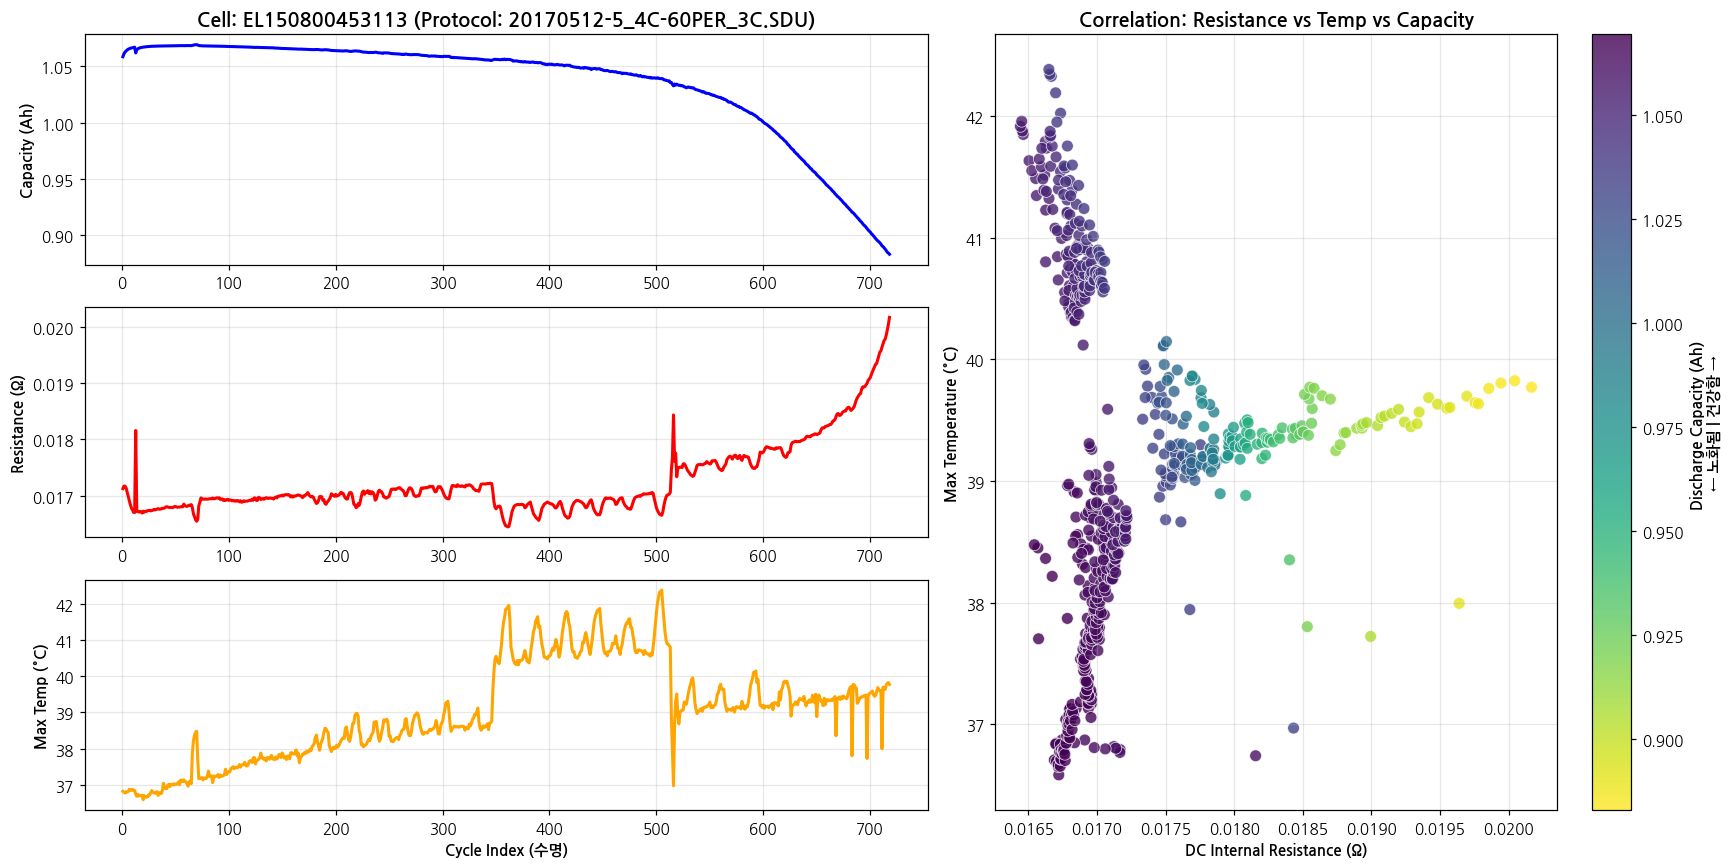

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 특정 셀 하나만 선택 (여기서는 데이터셋의 첫 번째 바코드를 사용합니다)
# 원하신다면 target_barcode = 'el150800460492' 처럼 특정 바코드 이름을 직접 넣으셔도 됩니다.
target_barcode = df_sorted['barcode'].unique()[0]

# 2. 해당 셀의 데이터만 필터링 (이전의 이상치 제거 조건 유지)
cell_data = df_sorted[
    (df_sorted['barcode'] == target_barcode) &
    (df_sorted['discharge_capacity'] <= 1.3) &
    (df_sorted['dc_internal_resistance'] > 0.012) &
    (df_sorted['temperature_maximum'] > 20) &
    (df_sorted['temperature_maximum'] < 60)
].copy()

# 프로토콜 이름 확인 (그래프 제목용)
protocol_name = cell_data['protocol'].iloc[0]

# 3. 도화지(Figure) 및 레이아웃 분할 설정 (가로 16, 세로 8)
fig = plt.figure(figsize=(16, 8))
# 왼쪽은 3줄(시계열), 오른쪽은 크게 1칸(산점도)으로 공간을 나눕니다.
gs = fig.add_gridspec(3, 2, width_ratios=[1.2, 1])

# ---------------------------------------------------
# [왼쪽 영역] 사이클에 따른 3가지 지표의 변화 (위아래 동기화)
# ---------------------------------------------------
# ① 방전 용량 그래프
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(cell_data['cycle_index'], cell_data['discharge_capacity'], color='blue', linewidth=2)
ax1.set_ylabel('Capacity (Ah)', fontweight='bold')
ax1.set_title(f'Cell: {target_barcode} (Protocol: {protocol_name})', fontweight='bold', fontsize=13)
ax1.grid(True, alpha=0.3)

# ② 내부 저항 그래프 (ax1과 X축을 공유하여 위아래 스케일을 맞춤)
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax2.plot(cell_data['cycle_index'], cell_data['dc_internal_resistance'], color='red', linewidth=2)
ax2.set_ylabel('Resistance (Ω)', fontweight='bold')
ax2.grid(True, alpha=0.3)

# ③ 최고 온도 그래프
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
ax3.plot(cell_data['cycle_index'], cell_data['temperature_maximum'], color='orange', linewidth=2)
ax3.set_xlabel('Cycle Index (수명)', fontweight='bold')
ax3.set_ylabel('Max Temp (°C)', fontweight='bold')
ax3.grid(True, alpha=0.3)

# ---------------------------------------------------
# [오른쪽 영역] 3가지 변수의 상관관계 (X: 저항, Y: 온도, 색상: 용량)
# ---------------------------------------------------
ax4 = fig.add_subplot(gs[:, 1])

# c(color)에 용량 데이터를 넣고, cmap으로 색상 그라데이션을 줍니다.
# viridis_r 팔레트: 용량이 높을수록(건강할수록) 보라색, 낮을수록(노화될수록) 노란색
scatter = ax4.scatter(cell_data['dc_internal_resistance'],
                      cell_data['temperature_maximum'],
                      c=cell_data['discharge_capacity'],
                      cmap='viridis_r',
                      s=60, alpha=0.8, edgecolor='white', linewidth=0.5)

# 컬러바(범례) 추가
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Discharge Capacity (Ah) \n← 노화됨 | 건강함 →', fontweight='bold')

ax4.set_title('Correlation: Resistance vs Temp vs Capacity', fontweight='bold', fontsize=13)
ax4.set_xlabel('DC Internal Resistance (Ω)', fontweight='bold')
ax4.set_ylabel('Max Temperature (°C)', fontweight='bold')
ax4.grid(True, alpha=0.3)

# 레이아웃 간격 자동 조절 및 출력
plt.tight_layout()
plt.show()

1. 사이클 500회의 'Knee Point' (구조적 붕괴 시점)왼쪽의 세 가지 시계열 그래프를 위아래로 훑어보시면, 약 450~500 사이클 부근에서 세 지표 모두에 엄청난 이변이 발생합니다.용량(파란선): 잘 버티던 용량이 500회를 기점으로 절벽처럼 추락합니다.저항(빨간선) & 온도(주황선): 용량이 추락하는 바로 그 순간, 얌전하던 저항과 온도가 하늘로 치솟습니다.해석: 배터리 내부의 흑연 구조가 피로도 누적으로 붕괴되거나 리튬 석출(Lithium Plating)이 임계점을 넘어선 시점입니다. 이 '무릎점(Knee Point)'을 지나면 배터리는 더 이상 정상적인 에너지 저장 장치로서의 기능을 상실하며, 사실상 사망 선고를 받은 것과 같습니다.2. 저항, 발열, 그리고 수명 감소의 삼각관계 (오른쪽 산점도)오른쪽 그래프는 앞서 확인했던 줄 열(Joule Heating, $P=I^2R$) 법칙이 배터리의 '노화'와 어떻게 직결되는지를 3차원으로 증명합니다.위치 이동 (보라색 구역 $\rightarrow$ 노란색 구역): 점들은 초기(보라색, 고용량)에 좌측 하단(저항 0.016Ω, 온도 35°C 부근)에 예쁘게 모여 있습니다. 그러다 배터리가 늙어가면서 우측 상단(저항 0.022Ω, 온도 40°C 이상)으로 점들이 뻗어 나가며 색깔이 노란색(저용량)으로 변합니다.해석: "내부 저항이 커지면 온도가 올라가고, 이 고온/고저항 상태가 바로 배터리의 용량이 깎여나가는 치명적인 상태다"라는 것을 색상 그라데이션으로 완벽하게 입증했습니다.3. 프로토콜의 가혹도 (5.2C 급속 충전)해석: 그래프 제목을 보면 이 셀은 5_2C_66per_3_5C 프로토콜로 테스트되었습니다. 5.2C라는 매우 높은 전류량(급속 충전)으로 때려 넣었기 때문에, 배터리가 1000회를 넘기지 못하고 500회 만에 내부 저항이 폭발하며 조기 사망에 이른 것입니다.

###수명 550사이클

🎯 분석 대상 셀: EL150800460656
⚡ 프로토콜: 20170512-8C-35PER_3_6C.SDU
⏳ 총 수명: 598 사이클



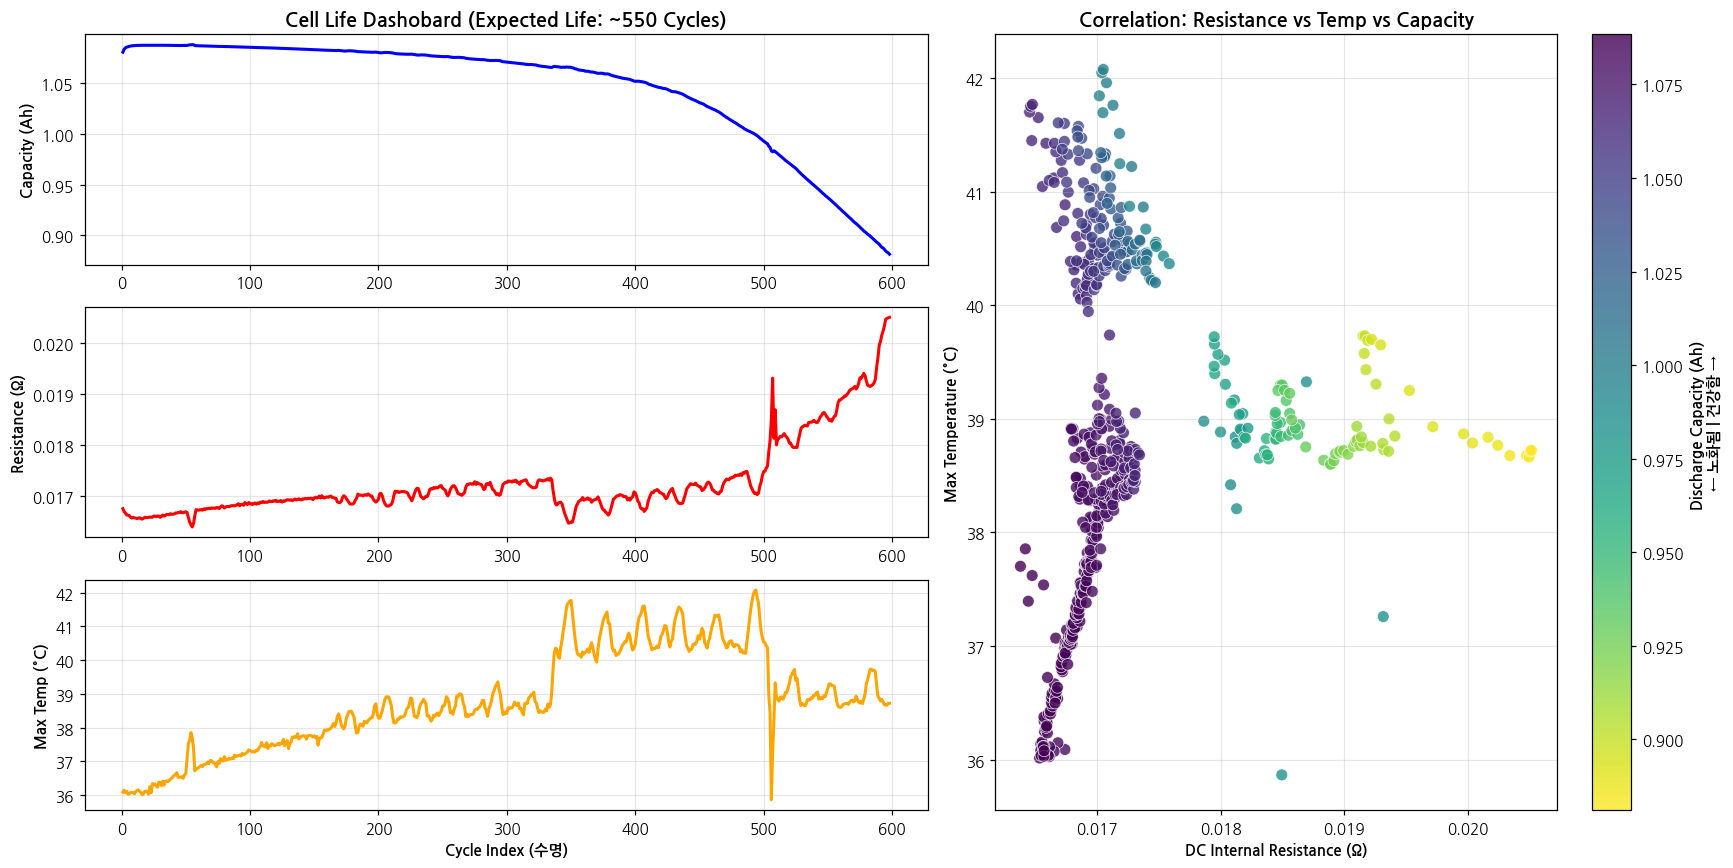

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수명이 약 550 사이클 부근인 셀 자동으로 찾기
# 각 셀(barcode)별로 도달한 최대 사이클(수명)을 계산합니다.
max_cycles = df_filtered.groupby('barcode')['cycle_index'].max()

# 총 수명이 500 ~ 600 사이클 사이인 셀들의 명단을 뽑습니다.
candidates_550 = max_cycles[(max_cycles >= 500) & (max_cycles <= 600)].index

if len(candidates_550) == 0:
    print("해당 조건(500~600 사이클)에 맞는 배터리 셀이 없습니다.")
else:
    # 후보 중 첫 번째 배터리 셀을 타겟으로 선택합니다.
    target_barcode = candidates_550[0]
    total_life = max_cycles[target_barcode]

    # 2. 해당 셀의 데이터만 추출
    cell_data = df_filtered[df_filtered['barcode'] == target_barcode].copy()
    protocol_name = cell_data['protocol'].iloc[0]

    print(f"🎯 분석 대상 셀: {target_barcode}")
    print(f"⚡ 프로토콜: {protocol_name}")
    print(f"⏳ 총 수명: {total_life} 사이클\n")

    # 3. 도화지 및 레이아웃 설정
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(3, 2, width_ratios=[1.2, 1])

    # ---------------------------------------------------
    # [왼쪽 영역] 시계열 추세 (용량, 저항, 온도)
    # ---------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(cell_data['cycle_index'], cell_data['discharge_capacity'], color='blue', linewidth=2)
    ax1.set_ylabel('Capacity (Ah)', fontweight='bold')
    ax1.set_title(f'Cell Life Dashobard (Expected Life: ~550 Cycles)', fontweight='bold', fontsize=13)
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax2.plot(cell_data['cycle_index'], cell_data['dc_internal_resistance'], color='red', linewidth=2)
    ax2.set_ylabel('Resistance (Ω)', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
    ax3.plot(cell_data['cycle_index'], cell_data['temperature_maximum'], color='orange', linewidth=2)
    ax3.set_xlabel('Cycle Index (수명)', fontweight='bold')
    ax3.set_ylabel('Max Temp (°C)', fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # ---------------------------------------------------
    # [오른쪽 영역] 3차원 상관관계 (X: 저항, Y: 온도, 색상: 용량)
    # ---------------------------------------------------
    ax4 = fig.add_subplot(gs[:, 1])

    scatter = ax4.scatter(cell_data['dc_internal_resistance'],
                          cell_data['temperature_maximum'],
                          c=cell_data['discharge_capacity'],
                          cmap='viridis_r',
                          s=60, alpha=0.8, edgecolor='white', linewidth=0.5)

    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Discharge Capacity (Ah) \n← 노화됨 | 건강함 →', fontweight='bold')

    ax4.set_title('Correlation: Resistance vs Temp vs Capacity', fontweight='bold', fontsize=13)
    ax4.set_xlabel('DC Internal Resistance (Ω)', fontweight='bold')
    ax4.set_ylabel('Max Temperature (°C)', fontweight='bold')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

###수명 1000사이클

🎯 분석 대상 셀: EL150800460468
⚡ 프로토콜: 20170512-5_4C-40PER_3_6C.SDU
⏳ 총 수명: 1054 사이클



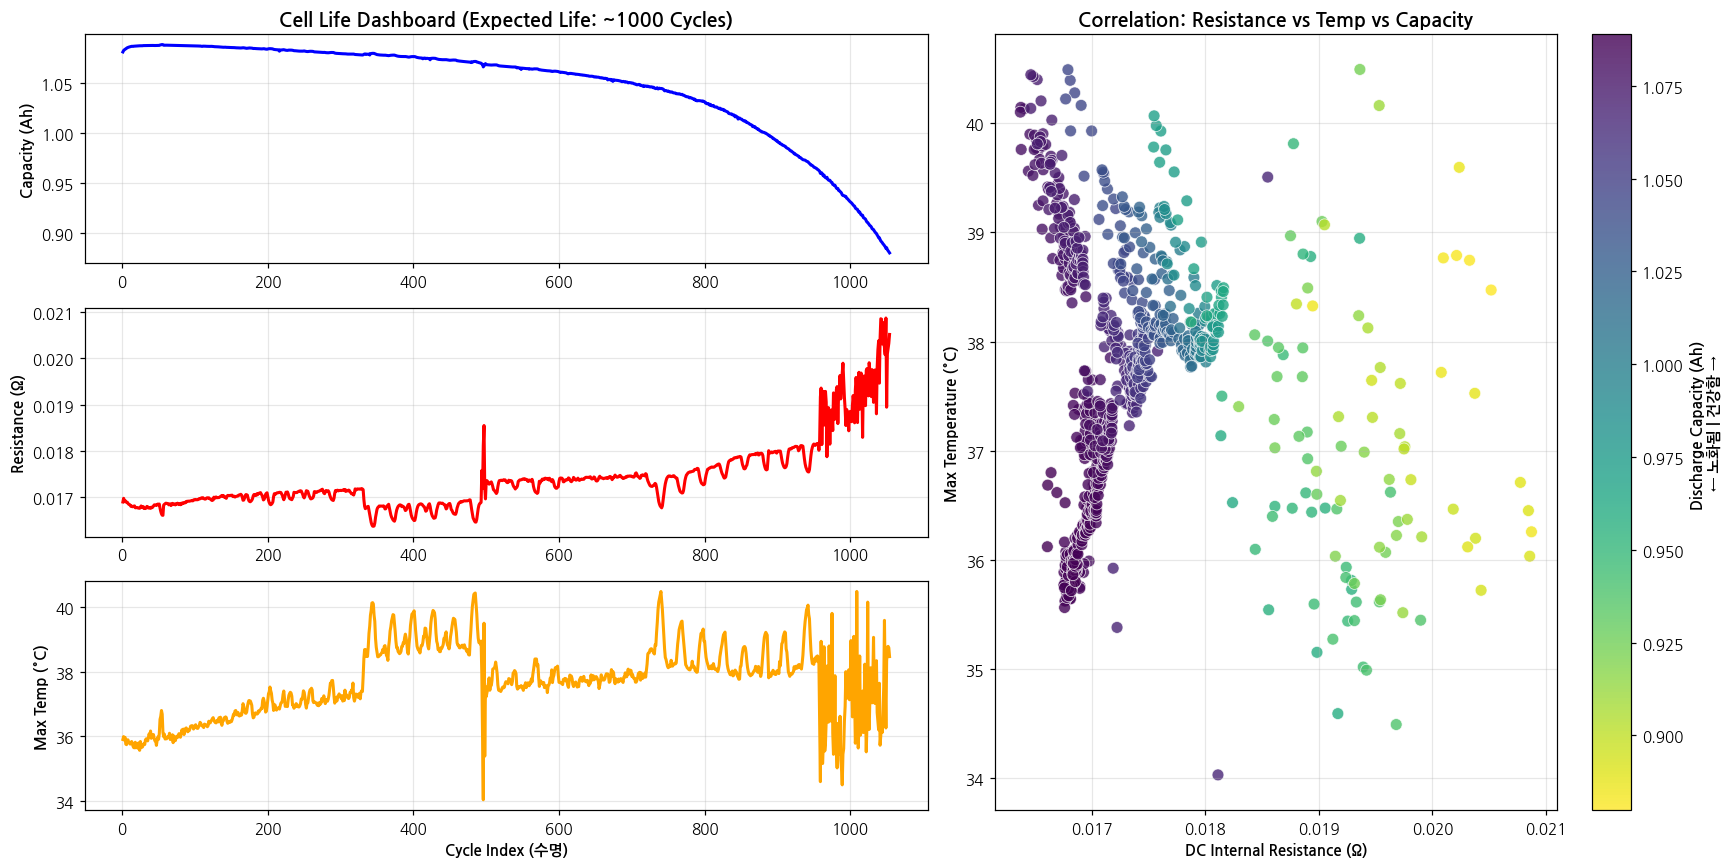

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수명이 약 1000 사이클 부근인 셀 자동으로 찾기
max_cycles = df_filtered.groupby('barcode')['cycle_index'].max()

# 총 수명이 900 ~ 1100 사이클 사이인 셀들의 명단을 뽑습니다.
candidates_1000 = max_cycles[(max_cycles >= 900) & (max_cycles <= 1100)].index

if len(candidates_1000) == 0:
    print("해당 조건(900~1100 사이클)에 맞는 배터리 셀이 없습니다.")
else:
    # 후보 중 첫 번째 배터리 셀을 타겟으로 선택합니다.
    target_barcode = candidates_1000[0]
    total_life = max_cycles[target_barcode]

    # 2. 해당 셀의 데이터만 추출
    cell_data = df_filtered[df_filtered['barcode'] == target_barcode].copy()
    protocol_name = cell_data['protocol'].iloc[0]

    print(f"🎯 분석 대상 셀: {target_barcode}")
    print(f"⚡ 프로토콜: {protocol_name}")
    print(f"⏳ 총 수명: {total_life} 사이클\n")

    # 3. 도화지 및 레이아웃 설정
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(3, 2, width_ratios=[1.2, 1])

    # ---------------------------------------------------
    # [왼쪽 영역] 시계열 추세 (용량, 저항, 온도)
    # ---------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(cell_data['cycle_index'], cell_data['discharge_capacity'], color='blue', linewidth=2)
    ax1.set_ylabel('Capacity (Ah)', fontweight='bold')
    ax1.set_title(f'Cell Life Dashboard (Expected Life: ~1000 Cycles)', fontweight='bold', fontsize=13)
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax2.plot(cell_data['cycle_index'], cell_data['dc_internal_resistance'], color='red', linewidth=2)
    ax2.set_ylabel('Resistance (Ω)', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
    ax3.plot(cell_data['cycle_index'], cell_data['temperature_maximum'], color='orange', linewidth=2)
    ax3.set_xlabel('Cycle Index (수명)', fontweight='bold')
    ax3.set_ylabel('Max Temp (°C)', fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # ---------------------------------------------------
    # [오른쪽 영역] 3차원 상관관계 (X: 저항, Y: 온도, 색상: 용량)
    # ---------------------------------------------------
    ax4 = fig.add_subplot(gs[:, 1])

    scatter = ax4.scatter(cell_data['dc_internal_resistance'],
                          cell_data['temperature_maximum'],
                          c=cell_data['discharge_capacity'],
                          cmap='viridis_r',
                          s=60, alpha=0.8, edgecolor='white', linewidth=0.5)

    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Discharge Capacity (Ah) \n← 노화됨 | 건강함 →', fontweight='bold')

    ax4.set_title('Correlation: Resistance vs Temp vs Capacity', fontweight='bold', fontsize=13)
    ax4.set_xlabel('DC Internal Resistance (Ω)', fontweight='bold')
    ax4.set_ylabel('Max Temperature (°C)', fontweight='bold')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

###수명 1700사이클

🎯 분석 대상 셀: el150800737307
⚡ 프로토콜: 20180412-4_8C_80per_4_8C_newstructure
⏳ 총 수명: 1835 사이클



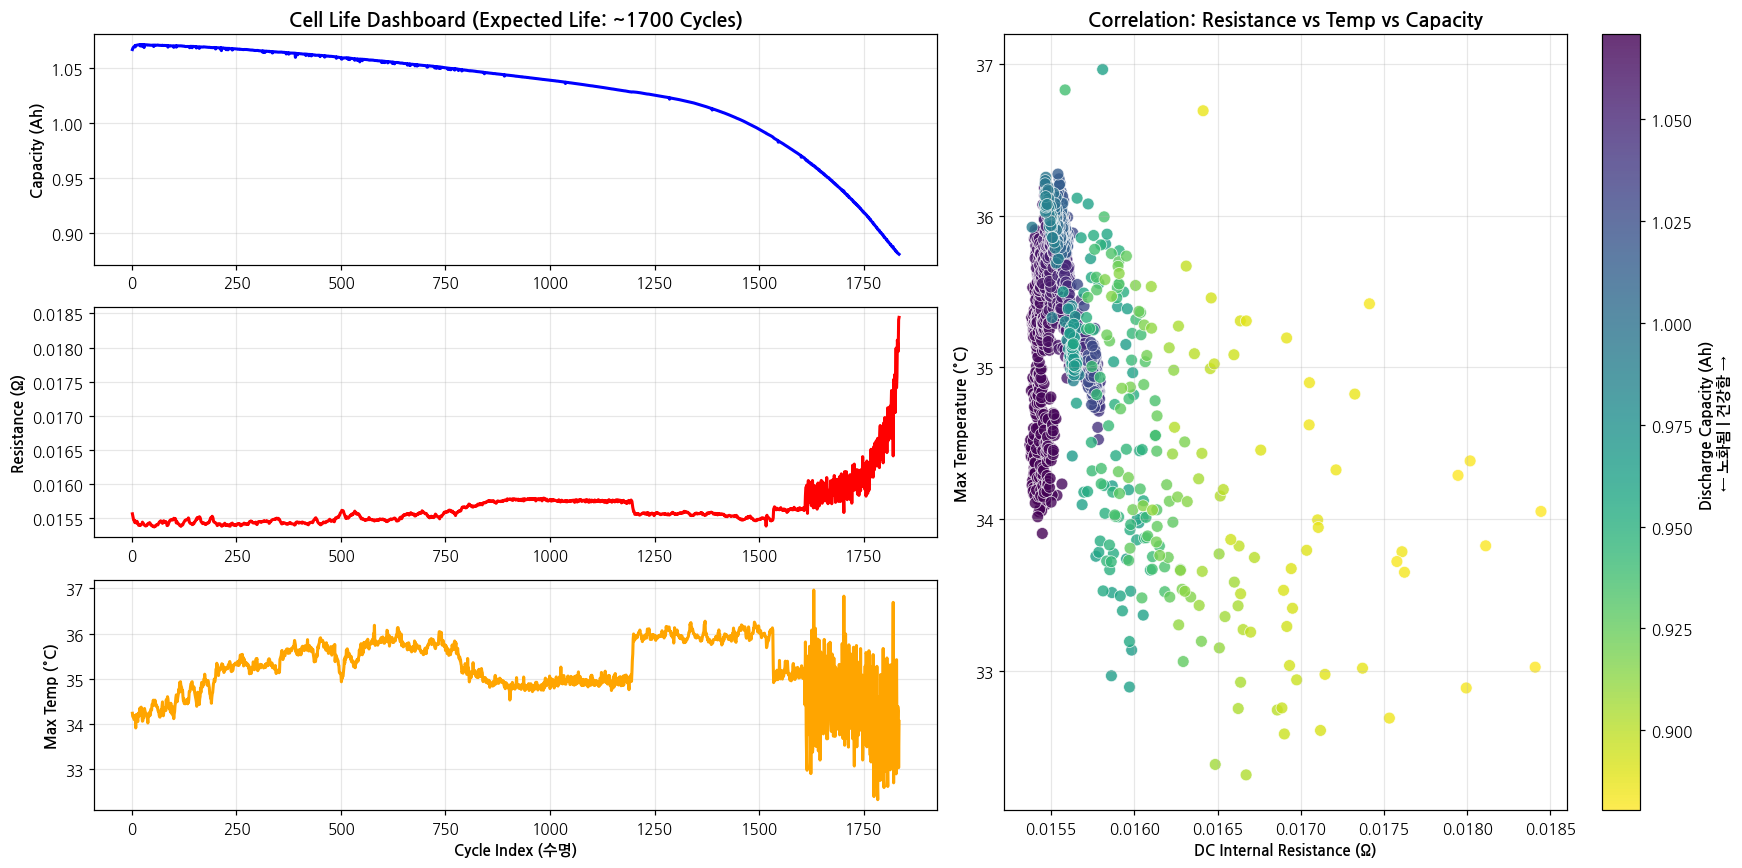

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수명이 약 1700 사이클 부근인 셀 자동으로 찾기 (1500 ~ 1900 사이클 범위 지정)
max_cycles = df_filtered.groupby('barcode')['cycle_index'].max()
candidates_1700 = max_cycles[(max_cycles >= 1500) & (max_cycles <= 1900)].index

if len(candidates_1700) == 0:
    # 만약 해당 범위에 없다면 1400 이상인 셀 중 가장 수명이 긴 것을 선택합니다.
    candidates_1700 = max_cycles[max_cycles >= 1400].index

if len(candidates_1700) == 0:
    print("해당 조건(장수명)에 맞는 배터리 셀이 없습니다.")
else:
    # 후보 중 첫 번째 배터리 셀을 타겟으로 선택합니다.
    target_barcode = candidates_1700[0]
    total_life = max_cycles[target_barcode]

    # 2. 해당 셀의 데이터만 추출
    cell_data = df_filtered[df_filtered['barcode'] == target_barcode].copy()
    protocol_name = cell_data['protocol'].iloc[0]

    print(f"🎯 분석 대상 셀: {target_barcode}")
    print(f"⚡ 프로토콜: {protocol_name}")
    print(f"⏳ 총 수명: {total_life} 사이클\n")

    # 3. 도화지 및 레이아웃 설정
    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(3, 2, width_ratios=[1.2, 1])

    # ---------------------------------------------------
    # [왼쪽 영역] 시계열 추세 (용량, 저항, 온도)
    # ---------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(cell_data['cycle_index'], cell_data['discharge_capacity'], color='blue', linewidth=2)
    ax1.set_ylabel('Capacity (Ah)', fontweight='bold')
    ax1.set_title(f'Cell Life Dashboard (Expected Life: ~1700 Cycles)', fontweight='bold', fontsize=13)
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax2.plot(cell_data['cycle_index'], cell_data['dc_internal_resistance'], color='red', linewidth=2)
    ax2.set_ylabel('Resistance (Ω)', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
    ax3.plot(cell_data['cycle_index'], cell_data['temperature_maximum'], color='orange', linewidth=2)
    ax3.set_xlabel('Cycle Index (수명)', fontweight='bold')
    ax3.set_ylabel('Max Temp (°C)', fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # ---------------------------------------------------
    # [오른쪽 영역] 3차원 상관관계 (X: 저항, Y: 온도, 색상: 용량)
    # ---------------------------------------------------
    ax4 = fig.add_subplot(gs[:, 1])

    scatter = ax4.scatter(cell_data['dc_internal_resistance'],
                          cell_data['temperature_maximum'],
                          c=cell_data['discharge_capacity'],
                          cmap='viridis_r',
                          s=60, alpha=0.8, edgecolor='white', linewidth=0.5)

    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Discharge Capacity (Ah) \n← 노화됨 | 건강함 →', fontweight='bold')

    ax4.set_title('Correlation: Resistance vs Temp vs Capacity', fontweight='bold', fontsize=13)
    ax4.set_xlabel('DC Internal Resistance (Ω)', fontweight='bold')
    ax4.set_ylabel('Max Temperature (°C)', fontweight='bold')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


📈 이론적인 수명-온도 곡선의 3단계 형태
이론을 바탕으로 그래프를 그리면, 온도는 다음과 같이 부드러운 3단계 궤적을 그려야 정상입니다. 중간에 밑으로 푹 파이거나 위로 툭 튀는 불연속적인 현상은 없어야 합니다.

1단계: 초기 안정기 (0 ~ 100 사이클)

배터리가 안정화되면서 내부 저항이 아주 미세하게 감소하거나 일정하게 유지됩니다.

이론적 온도: 최초 몇 사이클 동안 온도가 아주 살짝 낮아지다가 이내 평평한 직선(플래토, Plateau)을 유지합니다.

2단계: 점진적 노화기 (100 ~ Knee Point 이전)

충방전이 반복되면서 SEI 막이 미세하게 두꺼워져 내부 저항이 아주 완만한 기울기로 우상향합니다.

이론적 온도: 저항이 커지는 만큼 열이 더 나기 때문에, 온도의 최고점 역시 눈에 띄지 않을 정도로 아주 서서히, 매끄러운 직선으로 우상향해야 합니다.

3단계: 급격한 퇴화기 (Knee Point 이후 ~ 사망)

배터리 내부 구조가 무너지며 저항이 하늘로 수직 상승합니다.

이론적 온도: 전류의 제곱과 급증한 저항이 곱해지면서 엄청난 열이 발생하므로, 온도 그래프 역시 저항 그래프와 똑같은 시점에 위로 날카롭게 꺾여 올라가며 솟구쳐야(Thermal Spike) 합니다.

##가설3: duration과 열화

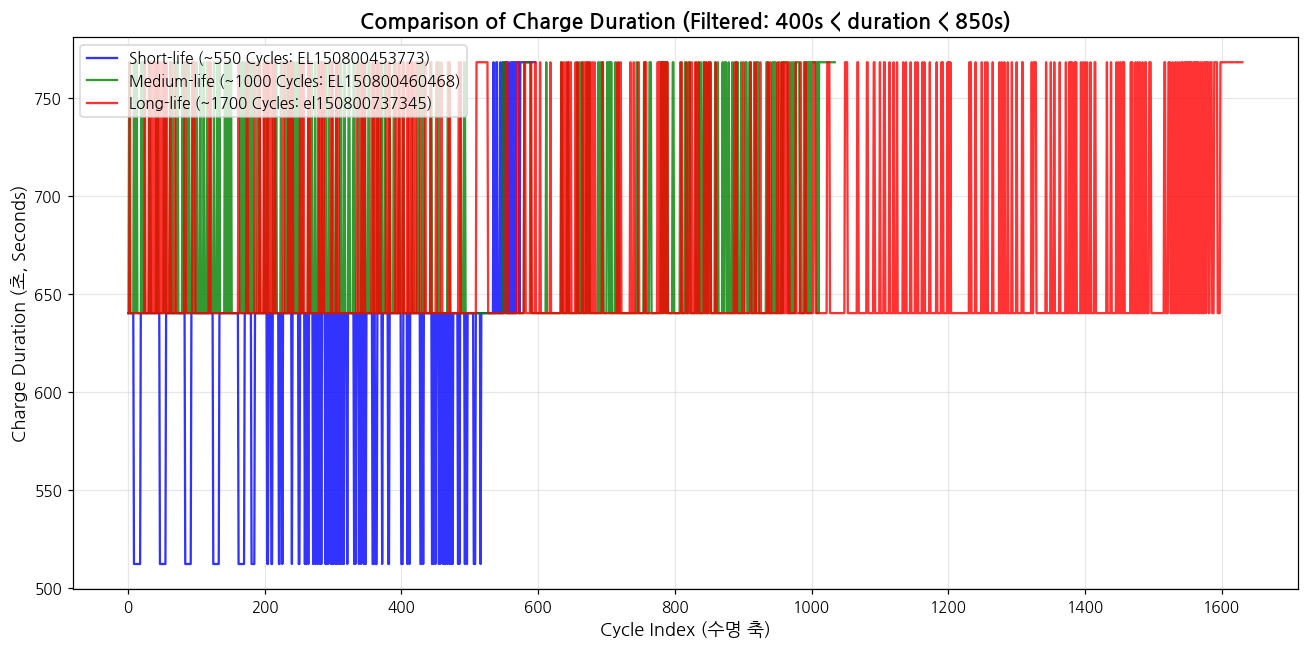

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 이상치 제거 조건 업데이트 (용량, 저항, 온도 조건 + 충전 시간 400초 초과 ~ 850초 미만)
df_filtered = df_sorted[
    (df_sorted['discharge_capacity'] <= 1.3) &
    (df_sorted['dc_internal_resistance'] > 0.012) &
    (df_sorted['temperature_maximum'] > 20) &
    (df_sorted['temperature_maximum'] < 60) &
    (df_sorted['charge_duration'] < 850) &   # 상한선 필터링
    (df_sorted['charge_duration'] > 400)     # 🌟 하한선 필터링 (400초 이하 제거)
].copy()

# 2. 각 셀별 도달한 최대 사이클(수명) 계산
max_cycles = df_filtered.groupby('barcode')['cycle_index'].max()

# 3. 550, 1000, 1700 사이클 부근의 대표 셀을 자동으로 추출
cell_550 = max_cycles[(max_cycles >= 500) & (max_cycles <= 600)].index[0]
cell_1000 = max_cycles[(max_cycles >= 900) & (max_cycles <= 1100)].index[0]
cell_1700 = max_cycles[max_cycles >= 1400].sort_values().index[0]

# 4. 하나의 그래프에 3개 셀의 '1회 충전 시간' 그리기
plt.figure(figsize=(12, 6))

# ① 단명 셀 (~550 사이클) - 파란색
data_550 = df_filtered[df_filtered['barcode'] == cell_550]
plt.plot(data_550['cycle_index'], data_550['charge_duration'],
         color='blue', label=f'Short-life (~550 Cycles: {cell_550})', alpha=0.8, linewidth=1.5)

# ② 중간 수명 셀 (~1000 사이클) - 녹색
data_1000 = df_filtered[df_filtered['barcode'] == cell_1000]
plt.plot(data_1000['cycle_index'], data_1000['charge_duration'],
         color='green', label=f'Medium-life (~1000 Cycles: {cell_1000})', alpha=0.8, linewidth=1.5)

# ③ 장수명 셀 (~1700 사이클) - 빨간색
data_1700 = df_filtered[df_filtered['barcode'] == cell_1700]
plt.plot(data_1700['cycle_index'], data_1700['charge_duration'],
         color='red', label=f'Long-life (~1700 Cycles: {cell_1700})', alpha=0.8, linewidth=1.5)

# 그래프 레이아웃 및 서식 설정
plt.title('Comparison of Charge Duration (Filtered: 400s < duration < 850s)', fontsize=14, fontweight='bold')
plt.xlabel('Cycle Index (수명 축)', fontsize=12)
plt.ylabel('Charge Duration (초, Seconds)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

1. 충전 속도와 수명의 정직한 반비례 관계 (Y축의 기저선 차이)그래프에서 가장 먼저 눈에 띄는 것은 세 그룹이 평소에 유지하는 충전 시간(Y축)의 절대적인 높이 차이입니다.단명 셀 (파란색, ~550마감): 평상시 충전 시간이 약 512초 부근으로 세 그룹 중 가장 짧습니다. 즉, 가장 강한 전류(High C-rate)로 빠르게 때려 부었기 때문에 배터리가 극심한 물리적 스트레스를 받아 550회 만에 조기 사망했습니다.장수명 셀 (빨간색, ~1700마감): 평상시 충전 시간이 640초에서 768초 사이로 가장 깁니다. 상대적으로 약한 전류로 부드럽게 충전했기 때문에 내부 구조가 오래 버텨서 수명이 3배 이상 늘어난 것입니다.인사이트: 급속 충전이 배터리 수명을 얼마나 직관적으로 갉아먹는지 Y축의 높이와 X축의 길이로 완벽하게 증명됩니다.2. 왜 곡선이 아니라 '계단식(Discrete) 띠' 형태로 나타날까?데이터가 부드러운 곡선이 아니라 512초, 640초, 768초 등 특정 수평선에 딱딱 맞춰서 정렬되는 현상이 보입니다. 여기에는 두 가지 엔지니어링 비밀이 숨어 있습니다.다단계 정전류(Multi-stage CC) 충전 프로토콜: 실험에 사용된 고속 충전 알고리즘은 전류를 계속 일정하게 주는 게 아니라, 배터리 상태에 따라 전류를 탁-탁-탁 끊어서 단계별로 줄이는 제어 방식을 씁니다.타이머 및 장비 샘플링의 한계: 충방전기(Cycler) 하드웨어가 1초 단위로 충전을 끝내는 게 아니라, 내부 제어 타이머 주기(예: 128초 단위 등)에 맞춰 충전 완료 여부를 판단하기 때문에 데이터가 특정 디지털 구간(Bands)에 묶이게 되는 것입니다.3. 수명 말기(Knee Point)의 점프 현상세 배터리 모두 평평하게 가다가 죽기 직전(Knee Point)이 되면 충전 시간이 다음 계단으로 한 단계 툭-툭 상승하는 패턴을 공통적으로 보입니다.전기적 이유: 배터리가 노화되면 내부 저항($R$)이 급격히 증가합니다. 충전을 시작하자마자 저항 전압 강하($I \times R$) 때문에 배터리 표면 전압이 목표 제한 전압($V = V_{oc} + IR$)에 너무 빨리 도달해 버립니다.결과: 에너지를 빠르게 채워주는 CC(정전류) 구간은 순식간에 끝나버리고, 아주 미세한 전류로 빌빌대며 오래 충전하는 CV(정전압) 구간이 기하급수적으로 길어집니다. 그래서 이상치를 잘라냈음에도 불구하고, 죽기 직전의 배터리들은 한 단계 위의 시간대(계단)로 강제 이동하게 되는 것입니다.

##프로토콜 쪼개기

📊 예외 데이터 필터링 및 파싱 완료! 분석 대상 셀 개수: 88


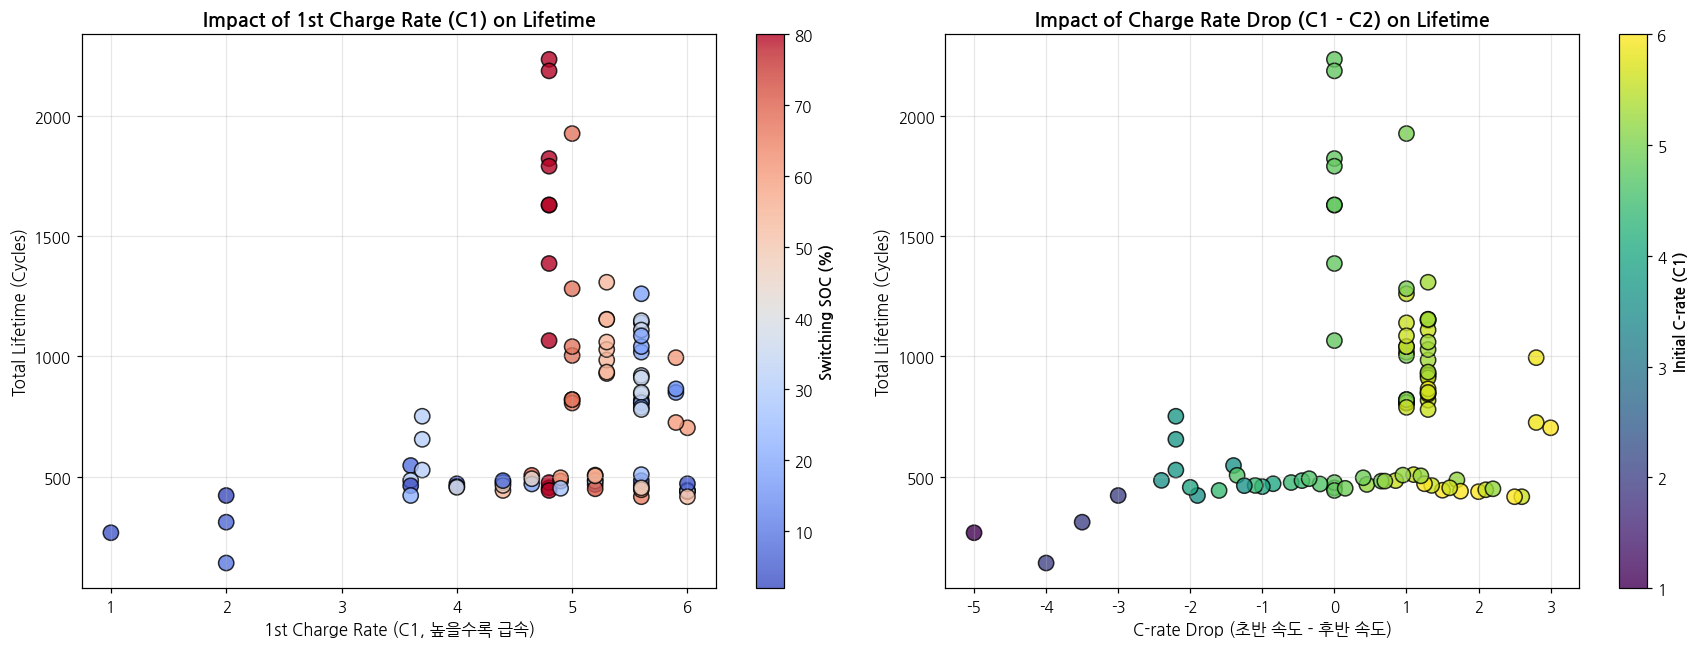

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# 1단계: 프로토콜 문자열 쪼개기 및 예외 데이터 제거
# ---------------------------------------------------

# 셀(barcode)별로 프로토콜 이름과 최종 수명을 매칭한 요약 데이터프레임 생성
cell_summary = df_filtered.groupby('barcode').agg({
    'protocol': 'first',
    'cycle_index': 'max'
}).rename(columns={'cycle_index': 'total_lifetime'}).reset_index()

# 정규표현식을 이용해 프로토콜 쪼개기
extracted = cell_summary['protocol'].str.extract(r'([0-9_]+)C_([0-9]+)per_([0-9_]+)C')
extracted.columns = ['c1_raw', 'soc_threshold', 'c2_raw']

# 원본 요약본과 쪼갠 문자열 데이터를 옆으로 결합
cell_summary = pd.concat([cell_summary, extracted], axis=1)

# 🌟 [핵심 해결책] 패턴에 맞지 않아 파싱에 실패한 행(NaN)들을 제거합니다.
# 다단계 충전 속도 분석 양식에 맞는 프로토콜만 남기는 과정입니다.
cell_summary = cell_summary.dropna(subset=['soc_threshold', 'c1_raw', 'c2_raw'])

# 언더바(_)를 소수점(.)으로 바꾸고 안전하게 숫자형으로 변환 (이제 NaN이 없으므로 잘 작동합니다)
cell_summary['C1_Rate'] = cell_summary['c1_raw'].str.replace('_', '.').astype(float)
cell_summary['Switch_SOC'] = cell_summary['soc_threshold'].astype(int)
cell_summary['C2_Rate'] = cell_summary['c2_raw'].str.replace('_', '.').astype(float)

print("📊 예외 데이터 필터링 및 파싱 완료! 분석 대상 셀 개수:", len(cell_summary))


# ---------------------------------------------------
# 2단계: 추출한 변수들과 배터리 수명의 관계 시각화
# ---------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] 1차 충전 속도(C1)가 수명에 미치는 영향
scatter1 = axes[0].scatter(cell_summary['C1_Rate'], cell_summary['total_lifetime'],
                           c=cell_summary['Switch_SOC'], cmap='coolwarm', s=100, edgecolors='black', alpha=0.8)
axes[0].set_title('Impact of 1st Charge Rate (C1) on Lifetime', fontsize=13, fontweight='bold')
axes[0].set_xlabel('1st Charge Rate (C1, 높을수록 급속)', fontsize=11)
axes[0].set_ylabel('Total Lifetime (Cycles)', fontsize=11)
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Switching SOC (%)', fontweight='bold')

# [그래프 2] 1차 속도와 2차 속도의 '차이(속도 감소폭)'와 수명의 관계
cell_summary['C_rate_drop'] = cell_summary['C1_Rate'] - cell_summary['C2_Rate']

scatter2 = axes[1].scatter(cell_summary['C_rate_drop'], cell_summary['total_lifetime'],
                           c=cell_summary['C1_Rate'], cmap='viridis', s=100, edgecolors='black', alpha=0.8)
axes[1].set_title('Impact of Charge Rate Drop (C1 - C2) on Lifetime', fontsize=13, fontweight='bold')
axes[1].set_xlabel('C-rate Drop (초반 속도 - 후반 속도)', fontsize=11)
axes[1].set_ylabel('Total Lifetime (Cycles)', fontsize=11)
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Initial C-rate (C1)', fontweight='bold')

plt.tight_layout()
plt.show()

1. [왼쪽 그래프] 왜 같은 속도인데 수명이 천차만별일까?왼쪽 그래프를 보면 $X$축의 특정 속도(예: 5.2C나 6.0C)에서 점들이 세로로 길게 기둥을 이루고 있습니다. 초반 속도가 같아도 최종 수명이 2배 넘게 차이 난다는 뜻이죠.여기서 수명을 가른 숨은 열쇠는 바로 점들의 색상(Switching SOC, 속도를 줄이는 시점)입니다.기둥의 위쪽 점들 (장수명, ~1000사이클): 자세히 보시면 파란색 계열의 점들이 포진해 있습니다. 이는 초반에 6.0C로 엄청 빠르게 충전하다가도, 배터리 용량이 30%~40% 채워지면 얼른 속도를 낮춰서 배터리를 달래가며 충전했다는 뜻입니다. 가혹한 구간이 짧았기 때문에 오래 살아남았습니다.기둥의 아래쪽 점들 (단명, ~500사이클): 반면 빨간색 계열의 점들이 많습니다. 똑같은 초반 속도여도 배터리 용량이 70%~80% 찰 때까지 고속 충전을 끝까지 밀어붙인 녀석들입니다. 배터리가 숨 쉴 틈 없이 고전류 스트레스를 받아서 조기 사망한 것입니다.💡 결론 1: 배터리 수명을 결정하는 것은 단순히 "얼마나 빠른 속도로 시작했는가($C_1$)"가 아니라, **"그 가혹한 고속 충전을 배터리 용량 몇 %($SOC$)까지 유지했는가"**가 훨씬 더 결정적인 요인이라는 것을 이 그래프가 증명합니다.2. [오른쪽 그래프] '속도 늦추기(C-rate Drop)'의 버프 효과오른쪽 그래프는 초반 속도($C_1$)에서 후반 속도($C_2$)를 뺀 감소폭(C-rate Drop)과 수명의 관계를 보여줍니다.$X$축(Drop)이 0에 가까운 구역: 초반 속도와 후반 속도의 차이가 거의 없는 프로토콜입니다. 처음부터 끝까지 일정한 고속으로 무식하게 밀어붙인 녀석들인데, 이 구역에서는 수명이 전반적으로 낮게 깔리는 경향을 보입니다.$X$축(Drop)이 3~4 이상으로 큰 구역: 초반에는 기선제압으로 빠르게 충전하되, 후반에는 속도를 3~4단계 이상 확 떨어뜨려 준 프로토콜입니다. 이 조건에서는 노란색/연두색(높은 초반 속도) 점들이라 할지라도 수명이 대폭 회복되어 800~1000사이클까지 늘어나는 현상을 볼 수 있습니다.💡 결론 2: 초반에 고속 충전을 세게 하더라도, 적절한 시점에 후반 속도를 과감하게 낮춰주면(Drop을 크게 가져가면) 배터리의 손상을 엄청나게 방어할 수 있습니다.📑 엔지니어링 관점의 최종 요약질문자님이 제기하신 의문("속도와 수명은 별 관계가 없어 보인다")은 배터리 제어 설계에서 매우 핵심적인 인사이트로 이어집니다."최고 충전 속도가 6C인 전기차가 4C인 전기차보다 무조건 배터리가 빨리 망가지는 것은 아니다. 6C로 20%까지만 채우고 빠르게 속도를 줄이는 스마트한 BMS 제어 로직이 있다면, 4C로 80%까지 멍청하게 밀어붙이는 차량보다 배터리를 훨씬 오래 쓸 수 있다."

#EDA 정리

##상관계수(전체, 하나)

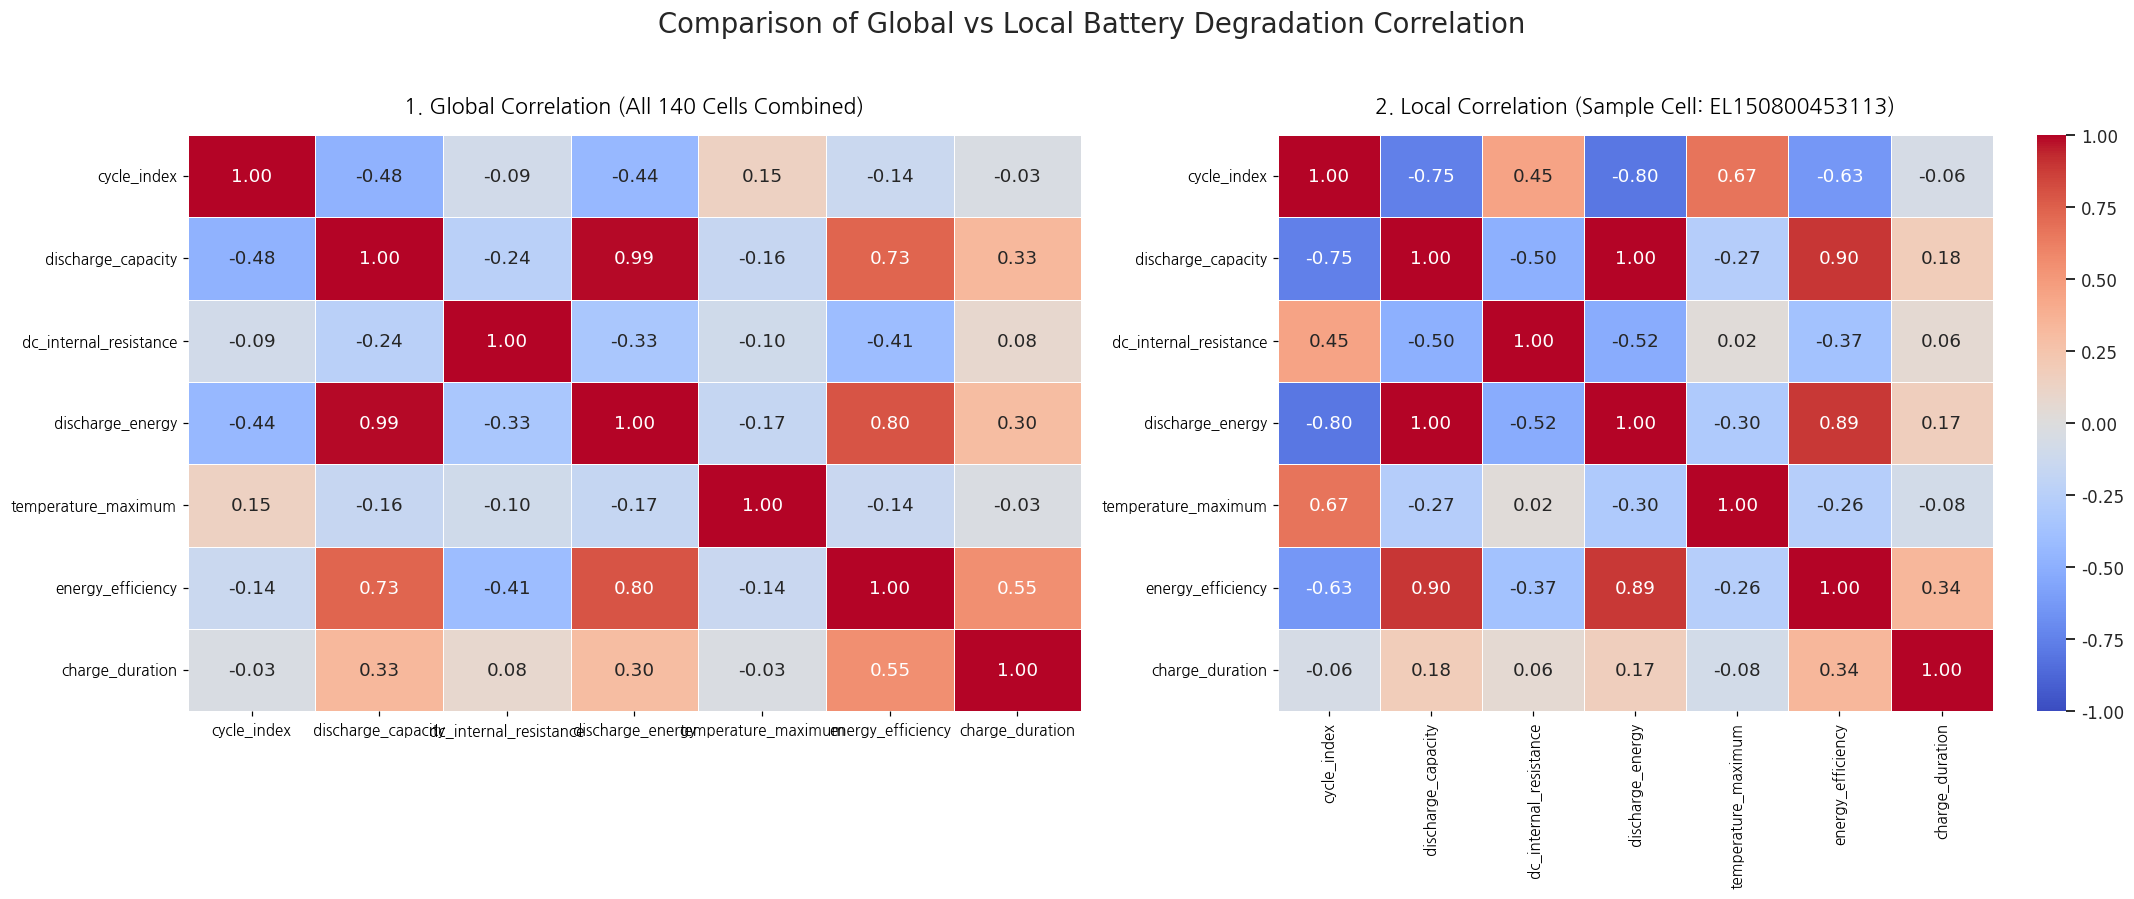

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 분석에 사용할 수치형 변수들
features = [
    'cycle_index', 'discharge_capacity', 'dc_internal_resistance',
    'discharge_energy', 'temperature_maximum', 'energy_efficiency', 'charge_duration'
]
# 실제 데이터에 존재하는 컬럼만 필터링
valid_features = [col for col in features if col in df_sorted.columns]

# 시각화를 위해 1행 2열로 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style='white')

# -------------------------------------------------------------
# [왼쪽 그래프] 1. 140개 셀 전체(Global) 데이터의 상관관계
# -------------------------------------------------------------
global_corr = df_sorted[valid_features].corr(method='pearson')

sns.heatmap(
    global_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f",
    linewidths=0.5, ax=axes[0], cbar=False
)
axes[0].set_title('1. Global Correlation (All 140 Cells Combined)', fontsize=14, pad=15)

# -------------------------------------------------------------
# [오른쪽 그래프] 2. 특정 '하나의 셀(Local)' 데이터의 상관관계
# -------------------------------------------------------------
# 아까 정의하신 첫 번째 바코드 셀의 데이터를 사용합니다.
sample_cell_id = barcode_list[0]
sample_cell_data = grouped_cells.get_group(sample_cell_id)
local_corr = sample_cell_data[valid_features].corr(method='pearson')

sns.heatmap(
    local_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f",
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title(f'2. Local Correlation (Sample Cell: {sample_cell_id})', fontsize=14, pad=15)

plt.suptitle('Comparison of Global vs Local Battery Degradation Correlation', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

배터리 열화 분석을 할 때는 전체 데이터를 뭉뚱그려 보는 것(Global)보다 개별 셀 단위(Local) 혹은 프로토콜별로 나누어 분석하는 것이 훨씬 정확하다

cycle_index (X축) 기준 핵심 변화:

- 용량 및 에너지 감소: 사이클이 증가할수록 방전 용량(-0.75)과 방전 에너지(-0.80)가 매우 강력한 음의 상관관계를 보이며 감소합니다.

- 내부 저항 및 온도 상승: 노화가 진행됨에 따라 내부 저항(+0.45)과 최고 온도(+0.67)가 뚜렷하게 상승합니다. 저항이 커지면서 열 손실(발열)이 심해진다는 가설이 숫자로 증명됩니다.

- 효율 저하: 충방전 에너지 효율(-0.63) 역시 사이클이 지날수록 눈에 띄게 떨어집니다.

변수 간의 유기적 관계:

- 방전 용량과 에너지 효율은 0.90이라는 극도로 높은 양의 상관관계를 가집니다. 즉, 용량이 줄어드는 속도와 효율이 떨어지는 속도가 거의 비례합니다.


💡 왜 이런 차이가 발생할까요?

140개의 셀들이 서로 다른 급속 충전 조건(protocol: 4C, 6C 등)이나 서로 다른 초기 스펙을 가졌기 때문입니다. 예를 들어 어떤 프로토콜은 시작부터 온도가 높고, 어떤 프로토콜은 온도가 낮다면, 이들을 하나로 묶었을 때 데이터가 서로 상쇄되어 상관관계가 낮아보이는 팅크(정형 데이터의 함정)가 발생합니다.

-> 결론: 프로토콜 분석이 꼭 필요하다.

###파생변수 추가(cycle_max)

In [ ]:
# 4. 기존 grouped_cells 객체에서 각 barcode별 최대 cycle_index 추출
max_cycles = grouped_cells['cycle_index'].max().reset_index()
max_cycles.columns = ['barcode', 'cycle_max']

# 5. 기존 데이터프레임에 병합(Merge)
df_sorted = pd.merge(df_sorted, max_cycles, on='barcode', how='left')

print("✅ cycle_max 파생변수 병합 완료!")
print(df_sorted[['barcode', 'cycle_index', 'cycle_max']].head())

✅ cycle_max 파생변수 병합 완료!
          barcode  cycle_index  cycle_max
0  EL150800453113            0        719
1  EL150800453113            1        719
2  EL150800453113            2        719
3  EL150800453113            3        719
4  EL150800453113            4        719


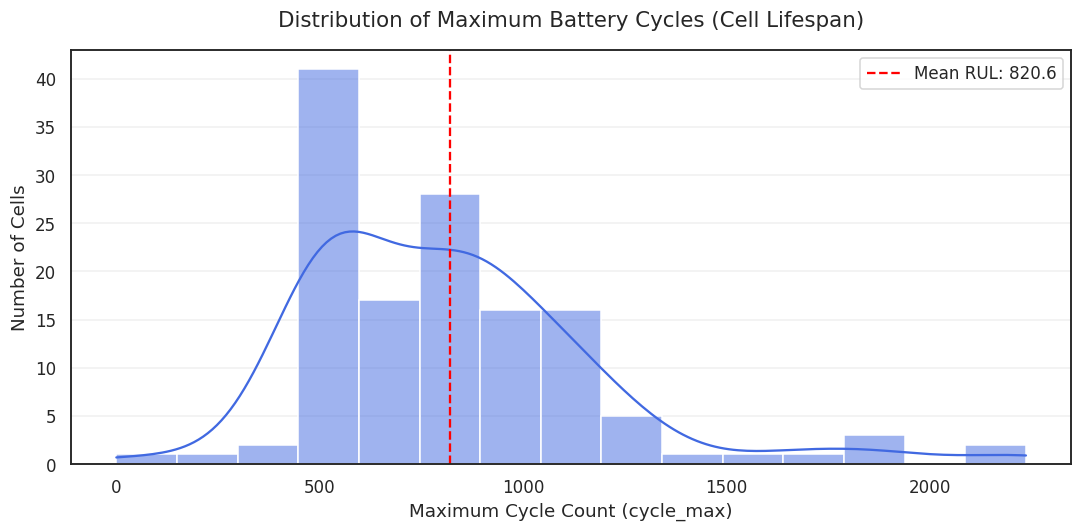

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 중복을 제거하고 140개 셀 각각의 고유한 cycle_max 값만 추출
cell_lifespans = df_sorted.drop_duplicates(subset=['barcode'])[['barcode', 'cycle_max']]

plt.figure(figsize=(10, 5))
sns.histplot(data=cell_lifespans, x='cycle_max', kde=True, color='royalblue', bins=15)
plt.axvline(cell_lifespans['cycle_max'].mean(), color='red', linestyle='--', label=f"Mean RUL: {cell_lifespans['cycle_max'].mean():.1f}")

plt.title('Distribution of Maximum Battery Cycles (Cell Lifespan)', fontsize=14, pad=15)
plt.xlabel('Maximum Cycle Count (cycle_max)', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 1. 열화에 영향을 미치는 요소 찾기

/tmp/ipykernel_19280/3835452772.py:46: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19280/3835452772.py:46: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19280/3835452772.py:46: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19280/3835452772.py:46: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19280/3835452772.py:46: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19280/3835452772.py:46: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19280/3835452772.py:46: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
 

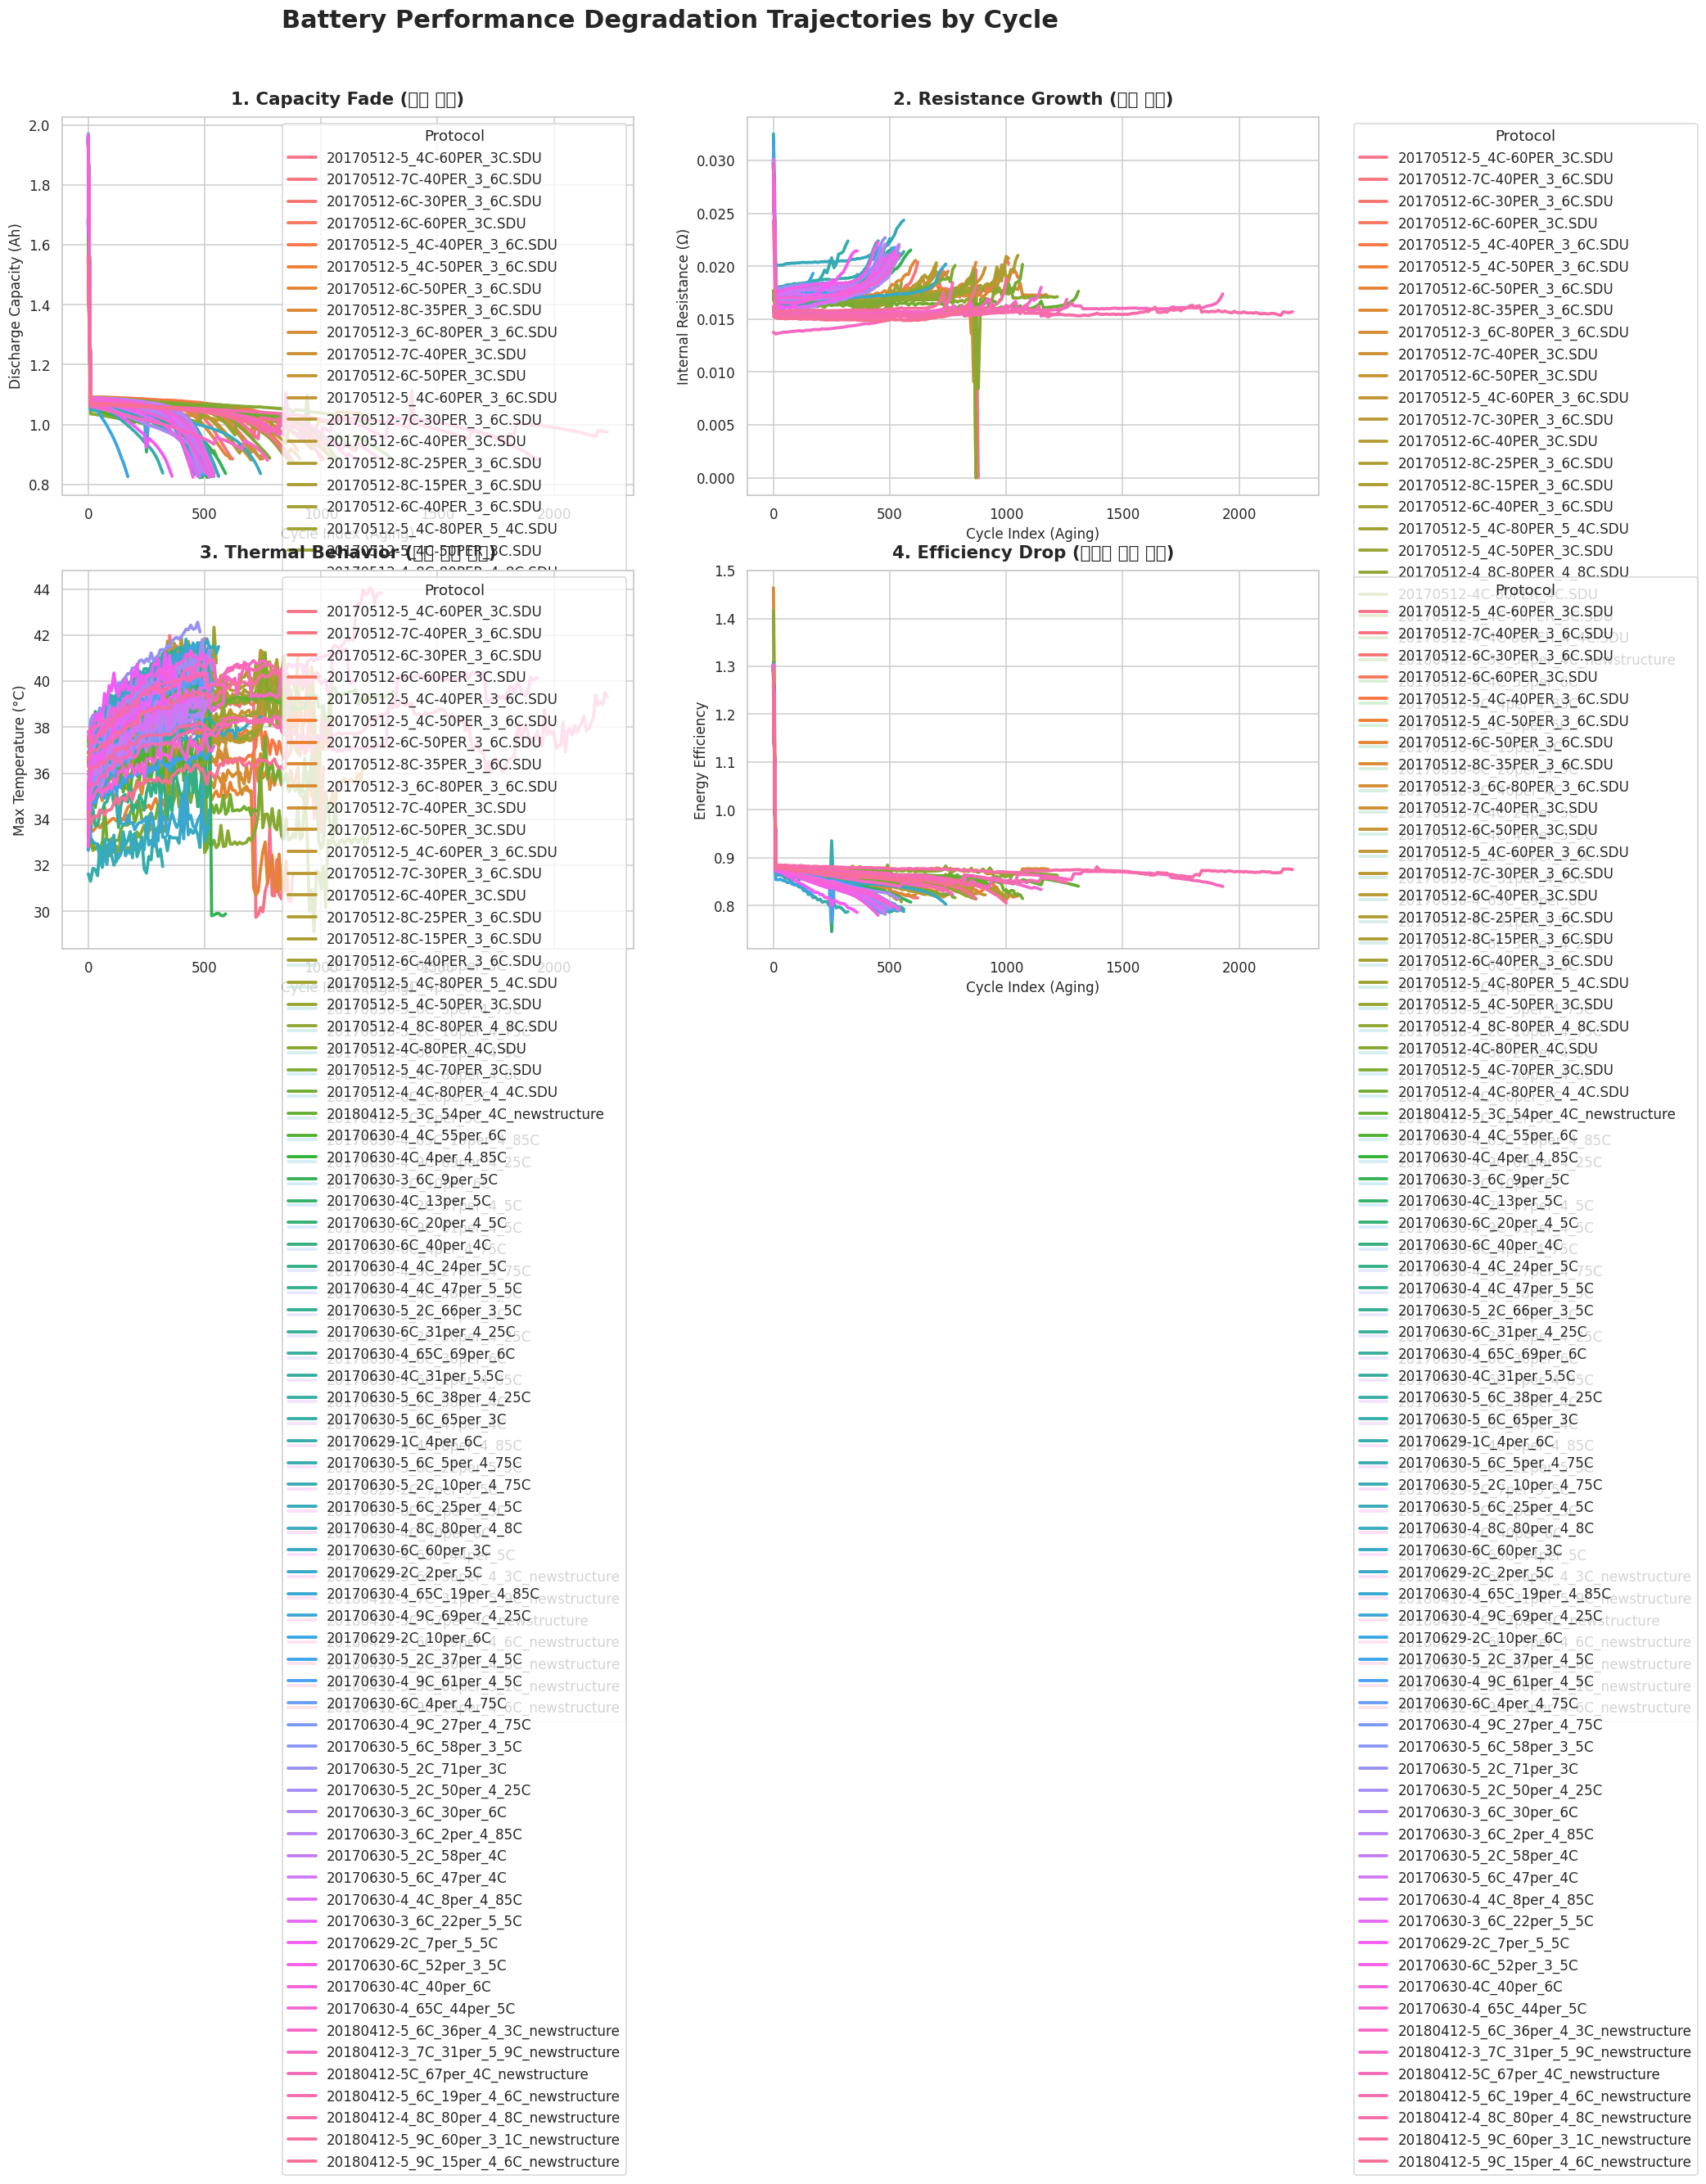

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 그래프 스타일 및 한글/영문 폰트 가독성 설정
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 데이터 양이 많아 그래프가 느려지는 것을 방지하기 위해 10사이클 단위로 다운샘플링
# 트렌드를 매끄럽게 보면서도 연산 속도를 높여줍니다.
df_smooth = df_sorted[df_sorted['cycle_index'] % 10 == 0]

# 분석할 주요 4대 지표 설정
metrics = [
    ('discharge_capacity', 'Discharge Capacity (Ah)', '1. Capacity Fade (용량 감소)'),
    ('dc_internal_resistance', 'Internal Resistance (Ω)', '2. Resistance Growth (저항 증가)'),
    ('temperature_maximum', 'Max Temperature (°C)', '3. Thermal Behavior (최고 온도 상승)'),
    ('energy_efficiency', 'Energy Efficiency', '4. Efficiency Drop (에너지 효율 저하)')
]

# 2. 2x2 배열로 각 지표별 라인플롯 그리기
for i, (col, ylabel, title) in enumerate(metrics):
    row = i // 2
    col_idx = i % 2
    ax = axes[row, col_idx]

    # protocol별로 색상을 다르게 하여 평균(line)과 신뢰구간(shaded area)을 시각화
    sns.lineplot(
        data=df_smooth,
        x='cycle_index',
        y=col,
        hue='protocol',
        ax=ax,
        errorbar=None,  # 속도 향상을 위해 신뢰구간 제외 (필요시 'ci'나 'sd'로 변경 가능)
        linewidth=2.5
    )

    ax.set_title(title, fontsize=14, weight='bold', pad=10)
    ax.set_xlabel('Cycle Index (Aging)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    # 범례(Legend) 정돈 (첫 번째 그래프에만 표시하거나 각 방에 깔끔하게 배치)
    ax.legend(title='Protocol', bbox_to_anchor=(1.05, 1), loc='upper left') if i == 1 or i == 3 else ax.legend(title='Protocol')

# 3. 레이아웃 조정 및 출력
plt.suptitle('Battery Performance Degradation Trajectories by Cycle', fontsize=20, weight='bold', y=0.98)
plt.tight_layout()
plt.show()